# 29 — AID 1851 auxiliary heads: full 5x5 CV confirmation

**Cold-start summary.** Notebook 28 screened AID 1851's efficacy readout as four
auxiliary heads alongside the four scored pIC50 heads, on **one fold at three seeds**, and
returned this project's **first resolved improvement in seven modelling screens**. A single
fold is a screen, not evidence. This notebook runs the same comparison under the project's
frozen **5x5 repeated cross-validation** and applies the Ash et al. statistical protocol
that notebook 05 established, so the comparison can be reported as a finding.

**Two arms only** — BASELINE (4 heads) and AID (8 heads) — **25 folds, one seed per fold**
taken from `outputs/05_cv_comparison/manifest.csv` so this run is directly comparable to
notebook 05's stored numbers. 50 runs.

**Nothing is changed from notebook 28 except the folds**, with one deliberate and necessary
exception: **winsorisation bounds are recomputed per fold** on that fold's own training
portion. Notebook 28 computed them once on a single fold's training portion; carrying those
fixed values across 25 folds would leak held-out information into 24 of them. The size of
that effect is reported in Part 2.

**Scope:** report only. No submission, no full-data retrain, no ensemble, no third arm.

## What is being confirmed

Notebook 28's single-fold result, **verified against its own saved
`run_scores.csv` in Part 0 below rather than retyped** (quoted values have been wrong three
times in this project):

| isoform | baseline | + AID | verdict |
|---|---|---|---|
| CYP1A2 | 0.7995 ± 0.0145 | 0.7306 | IMPROVES |
| CYP2C9 | 0.7142 ± 0.0158 | 0.6834 | IMPROVES |
| CYP2D6 | 0.9599 ± 0.0626 | 0.9150 | UNRESOLVED |
| CYP3A4 | 0.5223 ± 0.0313 | 0.5170 | UNRESOLVED |

**CYP1A2 is the clean case** — its three AID seeds sat entirely below its three baseline
seeds. **CYP2C9 cleared the frozen rule but its arm straddled the baseline**
(0.6037–0.7478 against 0.7000–0.7312), so its verdict is correct by the rule and fragile on
inspection. This run exists largely to settle that.

## Autonomy

This notebook was built and executed with the user away. It takes no interactive decisions.
Any specification gap was resolved by taking the option that changes least from notebook
28's already-executed configuration, and every such choice is recorded in the
**"Decisions taken without approval"** section near the end. That section is present even
if empty. On a hard failure the notebook writes a **"RUN ABORTED"** cell naming the exact
fold/arm/seed and stops cleanly with partial results on disk, rather than improvising.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata
import itertools
import json
import os
import subprocess
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.features import assign_screen_split, canonicalize_smiles, smiles_to_inchikey
from src.chemprop_screen import (
    build_predict_csv,
    build_training_csv,
    run_chemprop_predict,
    run_chemprop_train,
    setup_logging,
    verify_predictions,
)
from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS, REGRESSION_ENDPOINTS
from src.vendor.openadmet_eval.evaluate_predictions import add_macro_endpoint, score_activity_predictions

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "rdkit", "chemprop", "torch", "statsmodels"]:
    try:
        print(f"{pkg}: {importlib.metadata.version(pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
AUX_COLS = [f"{iso}_AID1851_max_inhibition" for iso in ISOFORMS]

PANEL_TO_ISOFORM = {
    "p450-cyp1a2": "CYP1A2", "p450-cyp2c9": "CYP2C9",
    "p450-cyp2d6": "CYP2D6", "p450-cyp3a4": "CYP3A4",
}

OUT = REPO_ROOT / "outputs" / "29_cv_confirmation"
FIG_OUT = OUT / "figures"
CHEMPROP_RUNS_DIR = OUT / "chemprop_runs"
PRED_DIR = OUT / "predictions"
SCORE_DIR = OUT / "scores"
LOG_DIR = REPO_ROOT / "logs" / "29_cv_confirmation"
for d in [OUT, FIG_OUT, CHEMPROP_RUNS_DIR, PRED_DIR, SCORE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

NB28_OUT = REPO_ROOT / "outputs" / "28_external_data"
FOLDS_PATH = REPO_ROOT / "data" / "folds" / "cv_folds.csv"
CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
BLIND_PATH = REPO_ROOT / "data" / "processed" / "test_blinded_curated.csv"
AID_CURATED_PATH = REPO_ROOT / "data" / "processed" / "aid1851_curated.csv"
AID_RAW_DIR = REPO_ROOT / "data" / "raw" / "aid1851"
MANIFEST_PATH = REPO_ROOT / "outputs" / "05_cv_comparison" / "manifest.csv"
STORED_05_SCORE_PATH = REPO_ROOT / "outputs" / "05_cv_comparison" / "scores" / "chemprop_chemeleoninit__repeat0_fold0.csv"

VAL_FRACTION = 0.15
EPOCHS = 50
PATIENCE = 5  # explicit -- --patience defaults to None, which silently disables early stopping
CHEMELEON_ARCH_ARGS = ["--from-foundation", "CHEMELEON", "--multi-hot-atom-featurizer-mode", "V2"]
WINSOR_LOW_PCT, WINSOR_HIGH_PCT = 1.0, 99.0
TOL = 1e-8

# chemprop is resolved by subprocess, so this interpreter's own env bin must be on PATH.
# Same block as scripts/10_final_retrain_predict.py -- cyp-admet-v2 is not under
# /opt/anaconda3, so `conda activate` is not the mechanism.
_env_bin = str(Path(sys.executable).parent)
_parts = os.environ.get("PATH", "").split(os.pathsep)
if _env_bin not in _parts:
    os.environ["PATH"] = os.pathsep.join([_env_bin, *_parts])
print(f"\nchemprop: {subprocess.run(['which','chemprop'],capture_output=True,text=True).stdout.strip()}")
print(f"OUT: {OUT}")

# Anything appended here is rendered in the "Decisions taken without approval" section.
RUN_STARTED_AT = time.time()
AUTONOMOUS_DECISIONS = []
ABORT = {"aborted": False, "reason": None, "where": None}

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
matplotlib: 3.11.1
rdkit: 2026.3.3
chemprop: 2.3.1
torch: 2.13.0
statsmodels: 0.14.6

chemprop: /Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/bin/chemprop
OUT: /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation


## Part 0 — Verifying everything this notebook builds on

`CLAUDE.md` records that quoted values carried between contexts have been wrong three times
in this project. Every notebook-28 figure used here as a reference is recomputed from
notebook 28's own saved `run_scores.csv`, and the run aborts if any disagrees.

In [2]:
nb28 = pd.read_csv(NB28_OUT / "run_scores.csv")
nb28_g = nb28.groupby(["arm", "Endpoint"])["ST-RAE"].agg(["mean", "std"])

CLAIMS = [
    ("baseline", "CYP1A2", 0.7995, 0.0145), ("aid", "CYP1A2", 0.7306, None),
    ("baseline", "CYP2C9", 0.7142, 0.0158), ("aid", "CYP2C9", 0.6834, None),
    ("baseline", "CYP2D6", 0.9599, 0.0626), ("aid", "CYP2D6", 0.9150, None),
    ("baseline", "CYP3A4", 0.5223, 0.0313), ("aid", "CYP3A4", 0.5170, None),
]
print(f"{'arm':9s} {'isoform':8s} {'claimed':>9s} {'recomputed':>11s} {'diff':>9s}  ok")
all_ok = True
for arm, iso, cm, cs in CLAIMS:
    ep = PIC50_COL[iso]
    m = float(nb28_g.loc[(arm, ep), "mean"])
    ok = abs(m - cm) < 0.001
    all_ok &= ok
    print(f"{arm:9s} {iso:8s} {cm:9.4f} {m:11.4f} {abs(m-cm):9.5f}  {ok}")
    if cs is not None:
        s = float(nb28_g.loc[(arm, ep), "std"])
        ok2 = abs(s - cs) < 0.001
        all_ok &= ok2
        print(f"{'':9s} {'(std)':8s} {cs:9.4f} {s:11.4f} {abs(s-cs):9.5f}  {ok2}")
assert all_ok, "a quoted notebook-28 figure does not reproduce -- HARD FAILURE"
print("\nAll notebook-28 ST-RAE figures reproduce exactly.")

# The CYP2C9 fragility this run exists to settle, verified rather than asserted.
for iso in ["CYP1A2", "CYP2C9"]:
    ep = PIC50_COL[iso]
    b = sorted(nb28[(nb28["arm"] == "baseline") & (nb28["Endpoint"] == ep)]["ST-RAE"])
    a = sorted(nb28[(nb28["arm"] == "aid") & (nb28["Endpoint"] == ep)]["ST-RAE"])
    sep = "COMPLETE separation" if max(a) < min(b) else "OVERLAPPING (straddles baseline)"
    print(f"  {iso}: baseline {[round(v,4) for v in b]}  aid {[round(v,4) for v in a]}  -> {sep}")

NB28_SINGLE_FOLD_VERDICT = {"CYP1A2": "IMPROVES", "CYP2C9": "IMPROVES",
                            "CYP2D6": "UNRESOLVED", "CYP3A4": "UNRESOLVED"}

arm       isoform    claimed  recomputed      diff  ok
baseline  CYP1A2      0.7995      0.7995   0.00005  True
          (std)       0.0145      0.0145   0.00005  True
aid       CYP1A2      0.7306      0.7306   0.00002  True
baseline  CYP2C9      0.7142      0.7142   0.00002  True
          (std)       0.0158      0.0158   0.00003  True
aid       CYP2C9      0.6834      0.6834   0.00004  True
baseline  CYP2D6      0.9599      0.9599   0.00004  True
          (std)       0.0626      0.0626   0.00002  True
aid       CYP2D6      0.9150      0.9150   0.00001  True
baseline  CYP3A4      0.5223      0.5223   0.00002  True
          (std)       0.0313      0.0313   0.00002  True
aid       CYP3A4      0.5170      0.5170   0.00003  True

All notebook-28 ST-RAE figures reproduce exactly.
  CYP1A2: baseline [0.7884, 0.7944, 0.8159]  aid [0.6995, 0.7256, 0.7666]  -> COMPLETE separation
  CYP2C9: baseline [0.7, 0.7113, 0.7312]  aid [0.6037, 0.6988, 0.7478]  -> OVERLAPPING (straddles baseline)


In [3]:
# Per-fold seeds from notebook 05's own manifest, so this run is directly comparable to
# 05's stored numbers. The manifest column is `seed`; notebook 05's per-fold score files
# record the same value as `bootstrap_seed` (confirmed against the stored file below).
manifest = pd.read_csv(MANIFEST_PATH)
mf = manifest[manifest["config"] == "chemprop_chemeleoninit"][["repeat", "fold", "repeat_col", "seed"]]
mf = mf.sort_values(["repeat", "fold"]).reset_index(drop=True)
assert len(mf) == 25, f"expected 25 (repeat, fold) rows, got {len(mf)}"
assert mf[["repeat", "fold"]].drop_duplicates().shape[0] == 25, "duplicate (repeat, fold) in manifest"

FOLD_SEED = {(int(r["repeat"]), int(r["fold"])): int(r["seed"]) for _, r in mf.iterrows()}
ALL_FOLDS = [(int(r["repeat"]), int(r["fold"])) for _, r in mf.iterrows()]
print(f"folds: {len(ALL_FOLDS)}   distinct seeds: {len(set(FOLD_SEED.values()))}")
print(mf.to_string(index=False))

_stored = pd.read_csv(STORED_05_SCORE_PATH)
_bs = _stored["bootstrap_seed"].unique()
print(f"\n05's repeat0_fold0 score file bootstrap_seed: {_bs}  |  manifest seed: {FOLD_SEED[(0,0)]}")
assert len(_bs) == 1 and int(_bs[0]) == FOLD_SEED[(0, 0)], \
    "manifest seed does not match 05's own stored bootstrap_seed -- HARD FAILURE"
print("confirmed: manifest `seed` is the same quantity as 05's stored `bootstrap_seed`.")

folds: 25   distinct seeds: 25
 repeat  fold repeat_col       seed
      0     0   repeat_0 2684470948
      0     1   repeat_0 4091952314
      0     2   repeat_0  233227757
      0     3   repeat_0 3276785861
      0     4   repeat_0 3644269654
      1     0   repeat_1 1206282609
      1     1   repeat_1 3543069911
      1     2   repeat_1 3479688010
      1     3   repeat_1  877132087
      1     4   repeat_1 1244265337
      2     0   repeat_2 2740186692
      2     1   repeat_2 3884972972
      2     2   repeat_2  829139639
      2     3   repeat_2 2545567356
      2     4   repeat_2 2718398101
      3     0   repeat_3  176092387
      3     1   repeat_3 3528048386
      3     2   repeat_3  569531098
      3     3   repeat_3 1337295874
      3     4   repeat_3  612016888
      4     0   repeat_4  232150720
      4     1   repeat_4 2324106676
      4     2   repeat_4 1658700540
      4     3   repeat_4  609942288
      4     4   repeat_4 3405943863

05's repeat0_fold0 score file bo

## Part 1 — The augmented training table

Rebuilt by notebook 28's own construction, reused rather than reimplemented: the same
efficacy readout (`max_inhibition = -Max_Response`, re-derived from
`data/raw/aid1851/batch_*.csv`), the same blind-750 exclusion, the same
attach-to-existing-rows handling of the 98 overlapping compounds, the same 8-head shape.

The one thing deliberately **not** carried over is the winsorisation, which Part 2 applies
per fold. `FULL_POP_RAW` below therefore holds **unclipped** auxiliary values.

The resulting table is asserted against notebook 28's own row count and auxiliary counts.
A mismatch is a hard failure.

In [4]:
aid_curated = pd.read_csv(AID_CURATED_PATH)

# Notebook 28 already re-derived Max_Response from the raw batches and cached it. Reuse
# that file READ-ONLY (outputs/28_external_data/ is out of scope for writes); rebuild into
# this notebook's own directory only if it is absent.
NB28_CACHE = NB28_OUT / "aid1851_max_response.csv"
LOCAL_CACHE = OUT / "aid1851_max_response.csv"

if NB28_CACHE.exists():
    aid_eff = pd.read_csv(NB28_CACHE)
    print(f"[reusing notebook 28's cache, read-only] {NB28_CACHE} ({len(aid_eff)} rows)")
elif LOCAL_CACHE.exists():
    aid_eff = pd.read_csv(LOCAL_CACHE)
    print(f"[cached] {LOCAL_CACHE} ({len(aid_eff)} rows)")
else:
    print("no cache found -- re-deriving Max_Response from the raw batches")
    frames = []
    for f in sorted(AID_RAW_DIR.glob("batch_*.csv")):
        df = pd.read_csv(f, low_memory=False)
        df = df[df["PUBCHEM_SID"].notna()]  # drop each batch's leading metadata rows
        frames.append(df)
    raw = pd.concat(frames, ignore_index=True)
    for col in ["PUBCHEM_SID", "PUBCHEM_CID", "Fit_LogAC50", "Max_Response"]:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")
    raw["isoform"] = raw["Panel Name"].map(PANEL_TO_ISOFORM)
    raw = raw[raw["isoform"].notna()].copy()
    raw = raw.dropna(subset=["PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES"]).copy()
    uniq = raw[["PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES"]].drop_duplicates("PUBCHEM_CID").copy()
    uniq["canonical_smiles"] = uniq["PUBCHEM_EXT_DATASOURCE_SMILES"].apply(canonicalize_smiles)
    uniq["inchikey"] = uniq["PUBCHEM_EXT_DATASOURCE_SMILES"].apply(smiles_to_inchikey)
    raw = raw.merge(uniq[["PUBCHEM_CID", "canonical_smiles", "inchikey"]], on="PUBCHEM_CID", how="left")
    raw = raw.dropna(subset=["inchikey"]).copy()
    aid_eff = raw.groupby(["inchikey", "isoform"], as_index=False).agg(
        max_response=("Max_Response", "mean"), n_replicates_eff=("Max_Response", "size"))
    aid_eff.to_csv(LOCAL_CACHE, index=False)
    print(f"wrote {LOCAL_CACHE}")

aid_eff["max_inhibition"] = -aid_eff["max_response"]

# Same assertion notebook 28 made: the re-derived population must match the curated one.
cur_counts = aid_curated["isoform"].value_counts().sort_index()
eff_counts = aid_eff["isoform"].value_counts().sort_index()
assert (cur_counts == eff_counts).all(), "re-derived population does not match aid1851_curated.csv -- HARD FAILURE"
assert set(aid_curated["inchikey"]) == set(aid_eff["inchikey"]), "compound sets differ -- HARD FAILURE"
print(f"per-isoform counts match curated: {dict(cur_counts)}")

aid = aid_curated.merge(aid_eff[["inchikey", "isoform", "max_response", "max_inhibition"]],
                        on=["inchikey", "isoform"], how="inner")
assert len(aid) == len(aid_curated), "join changed row count"
print(f"joined AID table: {aid.shape}")

[reusing notebook 28's cache, read-only] /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/28_external_data/aid1851_max_response.csv (66232 rows)
per-isoform counts match curated: {'CYP1A2': 16558, 'CYP2C9': 16558, 'CYP2D6': 16558, 'CYP3A4': 16558}
joined AID table: (66232, 8)


In [5]:
curated = pd.read_csv(CURATED_PATH)
blind = pd.read_csv(BLIND_PATH)
train_ik = set(curated["inchikey"].dropna())
blind_ik = set(blind["inchikey"].dropna())

BLIND_OVERLAP = sorted(set(aid["inchikey"]) & blind_ik)
print(f"AID compounds also in the blind 750 -- excluded ({len(BLIND_OVERLAP)}): {BLIND_OVERLAP}")
n0 = len(aid)
aid = aid[~aid["inchikey"].isin(blind_ik)].copy()
print(f"blind exclusion: {n0} -> {len(aid)} rows ({aid['inchikey'].nunique()} compounds)")
assert len(set(aid["inchikey"]) & blind_ik) == 0, "a blind compound survived exclusion -- HARD FAILURE"

# Pivot long -> wide, one auxiliary column per isoform.
aid_wide = aid.pivot(index="inchikey", columns="isoform", values="max_inhibition")
aid_wide.columns = [f"{c}_AID1851_max_inhibition" for c in aid_wide.columns]
aid_wide = aid_wide.reset_index().merge(
    aid[["inchikey", "canonical_smiles"]].drop_duplicates("inchikey"), on="inchikey", how="left")
aid_wide = aid_wide[["inchikey", "canonical_smiles"] + AUX_COLS]
assert aid_wide["inchikey"].is_unique, "duplicate inchikey after pivot"

curated_ik = set(curated["inchikey"].dropna())
BASE_COLS = ["Molecule_Name", "inchikey", "canonical_smiles"]

# The 98 overlapping compounds: auxiliary values ATTACH to their existing rows.
curated_part = curated[BASE_COLS + list(REGRESSION_ENDPOINTS)].copy()
n_before = len(curated_part)
curated_part = curated_part.merge(aid_wide[["inchikey"] + AUX_COLS], on="inchikey", how="left")
assert len(curated_part) == n_before, "merge changed row count"
n_attached = int(curated_part[AUX_COLS].notna().any(axis=1).sum())

# The AID-only compounds become new rows with NaN in all four scored columns.
extra_part = aid_wide[~aid_wide["inchikey"].isin(curated_ik)].copy()
extra_part["Molecule_Name"] = "AID1851_" + extra_part["inchikey"]
for c in REGRESSION_ENDPOINTS:
    extra_part[c] = np.nan
extra_part = extra_part[BASE_COLS + list(REGRESSION_ENDPOINTS) + AUX_COLS]

FULL_POP_RAW = pd.concat([curated_part, extra_part], ignore_index=True)
EXTRA_IK = set(extra_part["inchikey"])
print(f"curated rows {len(curated_part)} (attached AID values: {n_attached}) + "
      f"AID-only rows {len(extra_part)} = {len(FULL_POP_RAW)}")

assert FULL_POP_RAW["inchikey"].is_unique, "a compound appears twice"
assert FULL_POP_RAW["Molecule_Name"].is_unique, "duplicate Molecule_Name"
assert FULL_POP_RAW["canonical_smiles"].notna().all(), "a row has no SMILES"

# --- assert against notebook 28's own numbers; a mismatch is a HARD FAILURE ---
NB28_ROWS, NB28_ATTACHED, NB28_EXTRA, NB28_AUX_NONNULL = 21364, 98, 16459, 16557
checks = [
    ("FULL_POP row count", len(FULL_POP_RAW), NB28_ROWS),
    ("attached overlapping compounds", n_attached, NB28_ATTACHED),
    ("AID-only extra compounds", len(extra_part), NB28_EXTRA),
]
for c in AUX_COLS:
    checks.append((f"non-null {c}", int(FULL_POP_RAW[c].notna().sum()), NB28_AUX_NONNULL))
print()
ok = True
for name, got, want in checks:
    good = got == want
    ok &= good
    print(f"  {name:45s} got={got:6d}  nb28={want:6d}  {good}")
if not ok:
    ABORT.update({"aborted": True, "reason": "augmented table does not match notebook 28's construction",
                  "where": "Part 1 table assertion"})
assert ok, "augmented table does not match notebook 28 -- HARD FAILURE, abort"
print("\nconfirmed: table construction reproduces notebook 28 exactly.")

AID compounds also in the blind 750 -- excluded (1): ['RWZAIHHFBKOVIK-UHFFFAOYSA-N']
blind exclusion: 66232 -> 66228 rows (16557 compounds)
curated rows 4905 (attached AID values: 98) + AID-only rows 16459 = 21364

  FULL_POP row count                            got= 21364  nb28= 21364  True
  attached overlapping compounds                got=    98  nb28=    98  True
  AID-only extra compounds                      got= 16459  nb28= 16459  True
  non-null CYP1A2_AID1851_max_inhibition        got= 16557  nb28= 16557  True
  non-null CYP2C9_AID1851_max_inhibition        got= 16557  nb28= 16557  True
  non-null CYP2D6_AID1851_max_inhibition        got= 16557  nb28= 16557  True
  non-null CYP3A4_AID1851_max_inhibition        got= 16557  nb28= 16557  True

confirmed: table construction reproduces notebook 28 exactly.


## Part 2 — Per-fold winsorisation

**This is the one deliberate change from notebook 28, and it is a correction rather than a
variation.** Notebook 28 computed the 1st/99th-percentile clip bounds once, on
`repeat_0/fold_0`'s training portion. Reusing those fixed numbers across 25 folds would
mean 24 folds had their auxiliary column clipped using bounds computed partly from their
own held-out compounds — a small but real leak, and exactly the kind this project's rules
forbid.

Bounds are therefore recomputed per fold on that fold's own training portion (every row not
in that fold's `screen_test` set, which is seed-independent). The spread of the resulting
bounds across folds is reported below so the size of the effect is visible rather than
assumed, and the `repeat_0/fold_0` bounds are asserted to reproduce notebook 28's own
values as an internal consistency check.

In [6]:
cv_folds = pd.read_csv(FOLDS_PATH)
print(f"cv_folds.csv: {cv_folds.shape}  (READ-ONLY, never modified)")


def fold_test_inchikeys(repeat, fold):
    return set(cv_folds.loc[cv_folds[f"repeat_{repeat}"] == fold, "inchikey"])


def winsorise_for_fold(full_pop_raw, repeat, fold):
    # Bounds from this fold's OWN training portion only -- every row not held out in this
    # fold. Seed-independent: the held-out set is fixed by cv_folds.csv and only the inner
    # train/val split varies with seed.
    test_ik = fold_test_inchikeys(repeat, fold)
    train_mask = ~full_pop_raw["inchikey"].isin(test_ik)
    pop = full_pop_raw.copy()
    bounds = {}
    for c in AUX_COLS:
        vals = pop.loc[train_mask, c].dropna()
        lo = float(np.percentile(vals, WINSOR_LOW_PCT))
        hi = float(np.percentile(vals, WINSOR_HIGH_PCT))
        bounds[c] = (lo, hi)
        pop[c] = pop[c].clip(lower=lo, upper=hi)
    return pop, bounds, int(train_mask.sum())


# Compute the bounds for every fold up front so their spread can be reported.
bound_rows = []
for (r, f) in ALL_FOLDS:
    _, bnds, n_train = winsorise_for_fold(FULL_POP_RAW, r, f)
    row = {"repeat": r, "fold": f, "n_train_portion": n_train}
    for c in AUX_COLS:
        row[f"{c.split('_')[0]}_low"] = bnds[c][0]
        row[f"{c.split('_')[0]}_high"] = bnds[c][1]
    bound_rows.append(row)
bounds_df = pd.DataFrame(bound_rows)
bounds_df.to_csv(OUT / "winsor_bounds_by_fold.csv", index=False)

print("winsorisation bounds across the 25 folds -- spread of the per-fold values:")
print(f"{'isoform':9s} {'low min':>10s} {'low max':>10s} {'low range':>11s} "
      f"{'high min':>10s} {'high max':>10s} {'high range':>11s}")
for iso in ISOFORMS:
    lo, hi = bounds_df[f"{iso}_low"], bounds_df[f"{iso}_high"]
    print(f"{iso:9s} {lo.min():10.3f} {lo.max():10.3f} {lo.max()-lo.min():11.3f} "
          f"{hi.min():10.3f} {hi.max():10.3f} {hi.max()-hi.min():11.3f}")

# Internal consistency: fold (0,0) must reproduce notebook 28's own bounds, since the
# definition is identical there.
nb28_prereg = json.loads((NB28_OUT / "prereg.json").read_text())
nb28_bounds = nb28_prereg["winsorisation"]["bounds"]
_, b00, _ = winsorise_for_fold(FULL_POP_RAW, 0, 0)
print()
print("fold (0,0) bounds vs. notebook 28's own frozen values:")
max_bd = 0.0
for c in AUX_COLS:
    lo28, hi28 = nb28_bounds[c]["low"], nb28_bounds[c]["high"]
    d = max(abs(b00[c][0] - lo28), abs(b00[c][1] - hi28))
    max_bd = max(max_bd, d)
    print(f"  {c:40s} nb29=({b00[c][0]:.4f}, {b00[c][1]:.4f})  nb28=({lo28:.4f}, {hi28:.4f})  maxdiff={d:.2e}")
assert max_bd < TOL, "fold (0,0) bounds do not reproduce notebook 28's -- HARD FAILURE"
print(f"\nconfirmed: fold (0,0) reproduces notebook 28's bounds to {max_bd:.2e} < {TOL}.")

cv_folds.csv: (4905, 7)  (READ-ONLY, never modified)


winsorisation bounds across the 25 folds -- spread of the per-fold values:
isoform      low min    low max   low range   high min   high max  high range
CYP1A2       -13.206    -13.190       0.016    116.242    116.293       0.051
CYP2C9      -184.327   -184.301       0.026    121.180    121.182       0.002
CYP2D6       -29.330    -29.329       0.001    100.338    100.348       0.010
CYP3A4       -75.061    -74.543       0.518    108.118    108.126       0.009

fold (0,0) bounds vs. notebook 28's own frozen values:
  CYP1A2_AID1851_max_inhibition            nb29=(-13.2055, 116.2927)  nb28=(-13.2055, 116.2927)  maxdiff=0.00e+00
  CYP2C9_AID1851_max_inhibition            nb29=(-184.3271, 121.1819)  nb28=(-184.3271, 121.1819)  maxdiff=0.00e+00
  CYP2D6_AID1851_max_inhibition            nb29=(-29.3303, 100.3475)  nb28=(-29.3303, 100.3475)  maxdiff=0.00e+00
  CYP3A4_AID1851_max_inhibition            nb29=(-74.8921, 108.1265)  nb28=(-74.8921, 108.1265)  maxdiff=0.00e+00

confirmed: fold (0,0

In [7]:
def build_population(full_pop, repeat, fold, seed, arm):
    # assign_screen_split is src/features.py's existing unmodified split function, called
    # as notebooks 04a/18/20/22/28 call it. Extras are absent from cv_folds.csv so they
    # come back with a NaN screen_split and are assigned screen_inner_train explicitly --
    # never held out, never in the inner validation set.
    split_df = assign_screen_split(cv_folds, repeat_col=f"repeat_{repeat}", test_fold=fold,
                                   val_fraction=VAL_FRACTION, seed=seed)
    cols = BASE_COLS + list(REGRESSION_ENDPOINTS) + (AUX_COLS if arm == "aid" else [])
    src_pop = full_pop if arm == "aid" else full_pop[full_pop["inchikey"].isin(curated_ik)]
    pop = src_pop[cols].copy().merge(split_df[["inchikey", "screen_split"]], on="inchikey", how="left")
    assert len(pop) == len(src_pop), "merge changed row count"
    pop.loc[pop["screen_split"].isna(), "screen_split"] = "screen_inner_train"
    assert pop["screen_split"].isin(["screen_test", "screen_inner_train", "screen_inner_val"]).all()
    return pop


ARM_TARGET_COLS = {"baseline": list(REGRESSION_ENDPOINTS),
                   "aid": list(REGRESSION_ENDPOINTS) + AUX_COLS}

# Structural checks on a sample of folds, including the extremes of the fold list.
print("structural checks on the split construction:")
for (r, f) in [ALL_FOLDS[0], ALL_FOLDS[12], ALL_FOLDS[-1]]:
    seed = FOLD_SEED[(r, f)]
    wp, _, _ = winsorise_for_fold(FULL_POP_RAW, r, f)
    pa = build_population(wp, r, f, seed, "aid")
    pb = build_population(wp, r, f, seed, "baseline")
    ta = set(pa.loc[pa["screen_split"] == "screen_test", "Molecule_Name"])
    tb = set(pb.loc[pb["screen_split"] == "screen_test", "Molecule_Name"])
    va = set(pa.loc[pa["screen_split"] == "screen_inner_val", "inchikey"])
    assert ta == tb, f"held-out sets differ between arms at repeat {r} fold {f}"
    held_ik = set(pa.loc[pa["screen_split"] == "screen_test", "inchikey"])
    assert held_ik.isdisjoint(EXTRA_IK), f"an extra compound was held out at repeat {r} fold {f}"
    assert va.isdisjoint(EXTRA_IK), f"an extra compound is in the validation set at repeat {r} fold {f}"
    a_counts = pa["screen_split"].value_counts().to_dict()
    b_counts = pb["screen_split"].value_counts().to_dict()
    print(f"  repeat {r} fold {f} (seed {seed}): held-out identical ({len(ta)} compounds); "
          f"aid {a_counts}; baseline {b_counts}")
print("\nconfirmed: held-out sets identical across arms; extras never held out or validated on.")

structural checks on the split construction:


  repeat 0 fold 0 (seed 2684470948): held-out identical (981 compounds); aid {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
  repeat 2 fold 2 (seed 829139639): held-out identical (981 compounds); aid {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}


  repeat 4 fold 4 (seed 3405943863): held-out identical (981 compounds); aid {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}; baseline {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}

confirmed: held-out sets identical across arms; extras never held out or validated on.


**What Part 2 shows.** The per-fold winsorisation bounds barely move across the 25 folds —
the low bound ranges by 0.001–0.518 and the high bound by 0.002–0.051 across all folds,
against columns spanning roughly −184 to +121. So the leak that carrying notebook 28's
fixed bounds would have introduced is **real but small in magnitude**. Recomputing per fold
is still the correct thing to do — this project's rules do not permit a known leak on the
grounds that it is small — and the numbers above are what make its size visible rather than
assumed. Fold (0,0) reproduces notebook 28's own bounds exactly (0.00e+00), confirming the
two notebooks agree wherever they should.

## Part 3 — Training

50 runs: 25 folds x 2 arms, one seed per fold from notebook 05's manifest, the same seed
for both arms within a fold. **One run per cell**, each protected by an on-disk cache-skip
with a content check, so `nbconvert`'s per-cell timeout can never lose more than one run
and re-executing the notebook resumes rather than restarts.

Runs are ordered **fold by fold, baseline then AID**, so that an interrupted run always
leaves *complete pairs* on disk — which is the unit the paired statistics need. Scores are
appended to `run_scores.csv` after every single run, not at the end.

In [8]:
RUN_SCORES_PATH = OUT / "run_scores.csv"
TIMINGS_PATH = OUT / "run_timings.csv"

# Set by the budget cell after the first two runs are timed. Until then, all 25 folds.
ACTIVE_FOLDS = list(ALL_FOLDS)
FIRST_RUN_MIN_PER_EPOCH = {}


def _log_wall_minutes(tag):
    lp = LOG_DIR / f"{tag}.log"
    if not lp.exists():
        return None
    stamps = [l[:19] for l in lp.read_text().splitlines() if l[:2] == "20" and len(l) > 19 and l[4] == "-"]
    if len(stamps) < 2:
        return None
    t0 = datetime.strptime(stamps[0], "%Y-%m-%d %H:%M:%S")
    t1 = datetime.strptime(stamps[-1], "%Y-%m-%d %H:%M:%S")
    return (t1 - t0).total_seconds() / 60.0


def _last_epoch(tag):
    m = CHEMPROP_RUNS_DIR / tag / "model_0" / "trainer_logs" / "version_0" / "metrics.csv"
    if not m.exists():
        return None
    eps = [int(r.split(",")[0]) for r in m.read_text().splitlines()[1:] if r and r.split(",")[0].isdigit()]
    return max(eps) if eps else None


def _append_rows(path, new_rows, key_cols):
    # Incremental write: read what is on disk, drop any rows for this same key, append,
    # write back. Never deletes another fold's results.
    new_df = pd.DataFrame(new_rows)
    if path.exists():
        old = pd.read_csv(path)
        keys = set(map(tuple, new_df[key_cols].values.tolist()))
        mask = ~old[key_cols].apply(lambda r: tuple(r) in keys, axis=1)
        combined = pd.concat([old[mask], new_df], ignore_index=True)
    else:
        combined = new_df
    combined = combined.sort_values(key_cols).reset_index(drop=True)
    combined.to_csv(path, index=False)
    return combined


def score_and_append(repeat, fold, arm, seed, pred_df):
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(seed):
        scored = score_activity_predictions(pred_df, ground_truth, list(REGRESSION_ENDPOINTS))
        scored = add_macro_endpoint(scored, list(REGRESSION_ENDPOINTS), ACTIVITY_METRICS)
    scored.to_csv(SCORE_DIR / f"{arm}__r{repeat}f{fold}.csv", index=False)
    pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
    rows = []
    for endpoint in pe.index:
        row = {"repeat": repeat, "fold": fold, "arm": arm, "seed": seed, "Endpoint": endpoint}
        row.update(pe.loc[endpoint].to_dict())
        rows.append(row)
    return _append_rows(RUN_SCORES_PATH, rows, ["repeat", "fold", "arm", "Endpoint"])


def run_one(repeat, fold, arm):
    if ABORT["aborted"]:
        print(f"[skipped] run aborted earlier: {ABORT['reason']} (at {ABORT['where']})")
        return None
    if (repeat, fold) not in ACTIVE_FOLDS:
        print(f"[outside reduced design] repeat {repeat} fold {fold} -- not run")
        return None

    seed = FOLD_SEED[(repeat, fold)]
    tag = f"{arm}__r{repeat}f{fold}"
    cached_pred_path = PRED_DIR / f"{tag}.csv"

    wp, _, _ = winsorise_for_fold(FULL_POP_RAW, repeat, fold)
    population = build_population(wp, repeat, fold, seed, arm)
    target_cols = ARM_TARGET_COLS[arm]
    expected_names = set(population.loc[population["screen_split"] == "screen_test", "Molecule_Name"])

    if cached_pred_path.exists():
        cached = pd.read_csv(cached_pred_path)
        if set(cached["Molecule_Name"]) == expected_names and len(cached) == len(expected_names):
            print(f"  [cached] {tag}: reusing existing predictions (never overwritten)")
            score_and_append(repeat, fold, arm, seed, cached)
            return cached
        print(f"  [cache mismatch] {tag}: cached file does not match this population -- retraining.")

    run_dir = CHEMPROP_RUNS_DIR / tag
    run_dir.mkdir(parents=True, exist_ok=True)
    logger = setup_logging(LOG_DIR / f"{tag}.log", f"nb29_{tag}")

    t0 = time.time()
    try:
        train_csv = run_dir / "train_input.csv"
        build_training_csv(population, target_cols, train_csv, logger, require_all_targets=False)
        predict_csv = build_predict_csv(population, run_dir, logger)
        run_chemprop_train(train_csv, target_cols, run_dir, logger, CHEMELEON_ARCH_ARGS, EPOCHS, PATIENCE, seed)
        raw_pred_csv = run_dir / "raw_predictions.csv"
        run_chemprop_predict(run_dir / "model_0", predict_csv, raw_pred_csv, logger)
        verify_predictions(raw_pred_csv, expected_names, target_cols, logger)
    except Exception as exc:
        # One retry, per the autonomy rules; a second failure is a hard abort.
        print(f"  [retry] {tag} failed once ({type(exc).__name__}: {exc}) -- retrying once")
        try:
            run_chemprop_train(train_csv, target_cols, run_dir, logger, CHEMELEON_ARCH_ARGS, EPOCHS, PATIENCE, seed)
            raw_pred_csv = run_dir / "raw_predictions.csv"
            run_chemprop_predict(run_dir / "model_0", predict_csv, raw_pred_csv, logger)
            verify_predictions(raw_pred_csv, expected_names, target_cols, logger)
        except Exception as exc2:
            ABORT.update({"aborted": True,
                          "reason": f"Chemprop failed twice: {type(exc2).__name__}: {exc2}",
                          "where": f"arm={arm} repeat={repeat} fold={fold} seed={seed}"})
            print(f"  [HARD FAILURE] {tag}: {exc2}")
            return None
    elapsed = time.time() - t0

    pred_df = pd.read_csv(raw_pred_csv)
    pred_df.to_csv(cached_pred_path, index=False)

    ep = _last_epoch(tag)
    mpe = elapsed / 60.0 / (ep + 1) if ep is not None else None
    ref = FIRST_RUN_MIN_PER_EPOCH.get(arm)
    warn = ""
    if ref and mpe and mpe > 5 * ref:
        warn = (f"  *** SLOW-RUN WARNING: {mpe:.2f} min/epoch is >5x this arm's first run "
                f"({ref:.2f}). Continuing anyway -- notebook 28's degradation resolved "
                f"without intervention and aborting would lose the run. ***")
    if arm not in FIRST_RUN_MIN_PER_EPOCH and mpe:
        FIRST_RUN_MIN_PER_EPOCH[arm] = mpe

    _append_rows(TIMINGS_PATH, [{"repeat": repeat, "fold": fold, "arm": arm, "seed": seed,
                                 "wall_min": round(elapsed / 60.0, 3), "last_epoch": ep,
                                 "min_per_epoch": round(mpe, 3) if mpe else None}],
                 ["repeat", "fold", "arm"])
    score_and_append(repeat, fold, arm, seed, pred_df)
    print(f"  {tag}: {elapsed/60:.2f} min, {(ep or 0)+1} epochs, {mpe:.2f} min/epoch" if mpe
          else f"  {tag}: {elapsed/60:.2f} min")
    if warn:
        print(warn)
    return pred_df


RUN_ORDER = [(r, f, arm) for (r, f) in ALL_FOLDS for arm in ["baseline", "aid"]]
print(f"{len(RUN_ORDER)} runs planned, ordered fold-by-fold (baseline then aid) so an")
print("interruption always leaves complete pairs on disk.")
print(f"first six: {RUN_ORDER[:6]}")

50 runs planned, ordered fold-by-fold (baseline then aid) so an
interruption always leaves complete pairs on disk.
first six: [(0, 0, 'baseline'), (0, 0, 'aid'), (0, 1, 'baseline'), (0, 1, 'aid'), (0, 2, 'baseline'), (0, 2, 'aid')]


In [9]:
# RUN 1 of 50 -- BASELINE, repeat 0 fold 0. Timed separately for the budget projection,
# and the run the sanity check below compares against notebook 05.
t0 = time.time()
_ = run_one(0, 0, "baseline")
BASELINE_FIRST_MIN = (time.time() - t0) / 60
print(f"\nfirst BASELINE run wall time: {BASELINE_FIRST_MIN:.2f} min")

2026-09-18 04:30:38.211 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:38.212 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:30:38.212 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:38.212 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r0f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:41.039 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:41.039 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:41.040 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:41.040 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



first BASELINE run wall time: 0.05 min


### Sanity check — before anything is interpreted

The retrained baseline at `repeat_0/fold_0` is compared against notebook 05's own stored
numbers for the identical (config, repeat, fold, seed). Notebooks 18, 20, 22 and 28 all
matched to 0.0000. A difference beyond 0.03 would mean the environment or pipeline has
drifted and every number downstream would be uninterpretable, so this is a **hard failure**
that aborts the run rather than a warning.

In [10]:
stored_05 = pd.read_csv(STORED_05_SCORE_PATH)
stored_pe = stored_05.groupby("Endpoint")[METRIC_NAMES].mean()
_rs = pd.read_csv(RUN_SCORES_PATH)
retr = _rs[(_rs["arm"] == "baseline") & (_rs["repeat"] == 0) & (_rs["fold"] == 0)].set_index("Endpoint")

DISCREPANCY_FLAG_THRESHOLD = 0.03
print(f"{'Endpoint':35s} {'stored 05':>12s} {'retrained':>12s} {'abs diff':>10s}")
max_diff = 0.0
for endpoint in REGRESSION_ENDPOINTS:
    s = float(stored_pe.loc[endpoint, "ST-RAE"])
    r = float(retr.loc[endpoint, "ST-RAE"])
    max_diff = max(max_diff, abs(s - r))
    print(f"{endpoint:35s} {s:12.4f} {r:12.4f} {abs(s-r):10.4f}")
print(f"\nmax abs ST-RAE difference: {max_diff:.4f} (threshold {DISCREPANCY_FLAG_THRESHOLD})")

if max_diff > DISCREPANCY_FLAG_THRESHOLD:
    ABORT.update({"aborted": True,
                  "reason": f"baseline sanity check failed: max abs ST-RAE diff {max_diff:.4f} "
                            f"exceeds {DISCREPANCY_FLAG_THRESHOLD} vs. notebook 05's stored numbers",
                  "where": "arm=baseline repeat=0 fold=0"})
    print("\n*** HARD FAILURE -- see the RUN ABORTED section. No further runs will execute. ***")
else:
    print("OK: fold/seed/environment plumbing confirmed against notebook 05.")

Endpoint                               stored 05    retrained   abs diff
CYP1A2_pIC50_direct_inhibition            0.7884       0.7884     0.0000
CYP2C9_pIC50_direct_inhibition            0.7113       0.7113     0.0000
CYP2D6_pIC50_direct_inhibition            0.9580       0.9580     0.0000
CYP3A4_pIC50_direct_inhibition            0.4910       0.4910     0.0000

max abs ST-RAE difference: 0.0000 (threshold 0.03)
OK: fold/seed/environment plumbing confirmed against notebook 05.


In [11]:
# RUN 2 of 50 -- AID, repeat 0 fold 0. The expensive arm (21,364 rows vs. 4,905); its wall
# time drives the budget projection below.
t0 = time.time()
_ = run_one(0, 0, "aid")
AID_FIRST_MIN = (time.time() - t0) / 60
print(f"\nfirst AID run wall time: {AID_FIRST_MIN:.2f} min")

2026-09-18 04:30:41.093 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:41.094 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:30:41.094 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:41.095 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r0f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:43.928 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:43.928 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:43.929 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:43.929 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations



first AID run wall time: 0.05 min


### Budget projection — decided before the remaining 48 runs

Notebook 28's six runs took 4.08 h against a 1.98 h projection, because per-epoch time
degraded 10.6x mid-run on an unchanged workload. This projection is therefore treated as a
floor, not an estimate, and the reduction rules below are applied mechanically.

In [12]:
bl = _log_wall_minutes("baseline__r0f0") or BASELINE_FIRST_MIN
ad = _log_wall_minutes("aid__r0f0") or AID_FIRST_MIN
per_fold = bl + ad
proj25 = 25 * per_fold / 60.0
proj15 = 15 * per_fold / 60.0
proj5 = 5 * per_fold / 60.0
print(f"measured BASELINE run: {bl:6.2f} min   (4,905 rows, 4 heads)")
print(f"measured AID run:      {ad:6.2f} min   (21,364 rows, 8 heads)")
print(f"per fold (both arms):  {per_fold:6.2f} min")
print()
print(f"projected 25 folds / 50 runs: {proj25:6.2f} h")
print(f"projected 15 folds / 30 runs: {proj15:6.2f} h")
print(f"projected  5 folds / 10 runs: {proj5:6.2f} h")
print()

if proj25 <= 30.0:
    ACTIVE_FOLDS = list(ALL_FOLDS)
    DESIGN = "5x5 (25 folds, 50 runs)"
    print(f"Projection is within the 30 h ceiling -- running the FULL {DESIGN}.")
elif proj15 <= 60.0:
    ACTIVE_FOLDS = [(r, f) for (r, f) in ALL_FOLDS if r < 3]
    DESIGN = "3x5 (15 folds, 30 runs) -- REDUCED"
    msg = (f"Projected 25-fold total {proj25:.1f} h exceeds the 30 h ceiling. Reduced to the "
           f"FIRST THREE REPEATS: {DESIGN}, projected {proj15:.1f} h. A 3x5 design is still a "
           f"valid repeated-measures comparison.")
    print("*** DEVIATION ***", msg)
    AUTONOMOUS_DECISIONS.append({"decision": "Reduced from 5x5 to 3x5", "reason": msg,
                                 "alternatives": "Run all 25 folds (would exceed the stated 30 h ceiling); "
                                                 "abandon the run (explicitly ruled out by the brief).",
                                 "authority": "pre-specified reduction rule in the task brief"})
else:
    ACTIVE_FOLDS = [(r, f) for (r, f) in ALL_FOLDS if r < 1]
    DESIGN = "1x5 (5 folds, 10 runs) -- SCREEN, not a confirmation"
    msg = (f"Projected 15-fold total {proj15:.1f} h exceeds 60 h. Reduced to the FIRST REPEAT "
           f"only: {DESIGN}, projected {proj5:.1f} h. This is a screen, not a confirmation, and "
           f"must not be reported as one.")
    print("*** DEVIATION ***", msg)
    AUTONOMOUS_DECISIONS.append({"decision": "Reduced from 5x5 to 1x5 (screen only)", "reason": msg,
                                 "alternatives": "3x5 (still over the 60 h ceiling); abandon (ruled out).",
                                 "authority": "pre-specified reduction rule in the task brief"})

print(f"\nACTIVE design: {DESIGN}  ({len(ACTIVE_FOLDS)} folds, {2*len(ACTIVE_FOLDS)} runs)")
with open(OUT / "design.json", "w") as fh:
    json.dump({"design": DESIGN, "active_folds": [list(x) for x in ACTIVE_FOLDS],
               "baseline_first_min": bl, "aid_first_min": ad,
               "projected_25_h": proj25, "projected_15_h": proj15, "projected_5_h": proj5,
               "decided_at_utc": datetime.now(timezone.utc).isoformat()}, fh, indent=2)
print(f"wrote {OUT / 'design.json'}")

measured BASELINE run:   5.48 min   (4,905 rows, 4 heads)
measured AID run:       36.05 min   (21,364 rows, 8 heads)
per fold (both arms):   41.53 min

projected 25 folds / 50 runs:  17.31 h
projected 15 folds / 30 runs:  10.38 h
projected  5 folds / 10 runs:   3.46 h

Projection is within the 30 h ceiling -- running the FULL 5x5 (25 folds, 50 runs).

ACTIVE design: 5x5 (25 folds, 50 runs)  (25 folds, 50 runs)
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation/design.json


In [13]:
# RUN 3 of 50 -- BASELINE, repeat 0 fold 1
_ = run_one(0, 1, "baseline")

2026-09-18 04:30:43.984 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:43.985 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:30:43.985 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:43.986 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 708 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r0f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:46.819 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:30:46.820 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:46.820 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:46.820 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:46.821 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [14]:
# RUN 4 of 50 -- AID, repeat 0 fold 1
_ = run_one(0, 1, "aid")

2026-09-18 04:30:46.864 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:46.866 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:30:46.866 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:46.866 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 708 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r0f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:49.695 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:30:49.696 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:49.696 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:49.697 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:49.697 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [15]:
# RUN 5 of 50 -- BASELINE, repeat 0 fold 2
_ = run_one(0, 2, "baseline")

2026-09-18 04:30:49.737 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:49.739 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:30:49.739 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:49.739 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 694 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r0f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:52.570 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:30:52.571 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:52.571 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:52.572 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:52.572 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [16]:
# RUN 6 of 50 -- AID, repeat 0 fold 2
_ = run_one(0, 2, "aid")

2026-09-18 04:30:52.615 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:52.617 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:30:52.617 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:52.617 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 694 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r0f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:55.453 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:30:55.454 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:55.454 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:55.455 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:55.455 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [17]:
# RUN 7 of 50 -- BASELINE, repeat 0 fold 3
_ = run_one(0, 3, "baseline")

2026-09-18 04:30:55.494 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:55.496 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:30:55.496 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:55.496 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 702 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r0f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:30:58.354 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:30:58.355 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:30:58.355 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:30:58.356 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:30:58.356 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [18]:
# RUN 8 of 50 -- AID, repeat 0 fold 3
_ = run_one(0, 3, "aid")

2026-09-18 04:30:58.399 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:30:58.400 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:30:58.401 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:30:58.401 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 702 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r0f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:01.213 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:01.213 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:01.214 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:01.214 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:01.214 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [19]:
# RUN 9 of 50 -- BASELINE, repeat 0 fold 4
_ = run_one(0, 4, "baseline")

2026-09-18 04:31:01.255 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:01.257 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:01.257 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:01.257 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r0f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:04.111 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:04.111 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:04.112 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:04.112 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:04.113 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [20]:
# RUN 10 of 50 -- AID, repeat 0 fold 4
_ = run_one(0, 4, "aid")

2026-09-18 04:31:04.155 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:04.156 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:04.156 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:04.157 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 685 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r0f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:06.997 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:06.997 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:06.997 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:06.998 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:06.998 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [21]:
# RUN 11 of 50 -- BASELINE, repeat 1 fold 0
_ = run_one(1, 0, "baseline")

2026-09-18 04:31:07.039 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:07.040 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:07.041 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:07.041 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 693 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r1f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:09.880 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:09.880 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:09.881 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:09.881 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:09.882 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [22]:
# RUN 12 of 50 -- AID, repeat 1 fold 0
_ = run_one(1, 0, "aid")

2026-09-18 04:31:09.924 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:09.926 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:09.926 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:09.926 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 693 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r1f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:12.749 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:12.749 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:12.750 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:12.750 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:12.751 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [23]:
# RUN 13 of 50 -- BASELINE, repeat 1 fold 1
_ = run_one(1, 1, "baseline")

2026-09-18 04:31:12.791 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:12.792 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:12.793 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:12.793 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 674 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r1f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:15.632 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:15.633 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:15.633 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:15.634 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:15.634 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [24]:
# RUN 14 of 50 -- AID, repeat 1 fold 1
_ = run_one(1, 1, "aid")

2026-09-18 04:31:15.677 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:15.678 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:15.678 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:15.678 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 674 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r1f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:18.516 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:18.516 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:18.517 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:18.517 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:18.517 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [25]:
# RUN 15 of 50 -- BASELINE, repeat 1 fold 2
_ = run_one(1, 2, "baseline")

2026-09-18 04:31:18.558 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:18.559 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:18.559 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:18.559 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 694 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r1f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:21.399 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:21.399 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:21.399 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:21.400 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:21.400 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [26]:
# RUN 16 of 50 -- AID, repeat 1 fold 2
_ = run_one(1, 2, "aid")

2026-09-18 04:31:21.442 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:21.444 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:21.444 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:21.444 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 694 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r1f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:24.279 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:24.279 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:24.280 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:24.280 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:24.281 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [27]:
# RUN 17 of 50 -- BASELINE, repeat 1 fold 3
_ = run_one(1, 3, "baseline")

2026-09-18 04:31:24.321 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:24.322 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:24.322 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:24.322 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 729 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r1f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:27.155 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:27.156 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:27.156 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:27.157 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:27.157 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [28]:
# RUN 18 of 50 -- AID, repeat 1 fold 3
_ = run_one(1, 3, "aid")

2026-09-18 04:31:27.200 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:27.202 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:27.202 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:27.202 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 729 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r1f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:30.060 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:30.060 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:30.061 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:30.061 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:30.062 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [29]:
# RUN 19 of 50 -- BASELINE, repeat 1 fold 4
_ = run_one(1, 4, "baseline")

2026-09-18 04:31:30.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:30.103 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:30.103 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:30.103 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 703 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r1f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:32.956 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:32.956 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:32.957 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:32.957 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:32.958 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [30]:
# RUN 20 of 50 -- AID, repeat 1 fold 4
_ = run_one(1, 4, "aid")

2026-09-18 04:31:33.000 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:33.002 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:33.002 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:33.002 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 703 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r1f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:35.828 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:35.829 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:35.829 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:35.829 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:35.830 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [31]:
# RUN 21 of 50 -- BASELINE, repeat 2 fold 0
_ = run_one(2, 0, "baseline")

2026-09-18 04:31:35.872 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:35.873 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:35.873 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:35.873 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r2f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:38.701 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:38.701 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:38.702 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:38.702 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:38.703 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [32]:
# RUN 22 of 50 -- AID, repeat 2 fold 0
_ = run_one(2, 0, "aid")

2026-09-18 04:31:38.745 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:38.746 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:38.746 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:38.747 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r2f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:41.578 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:41.579 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:41.579 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:41.580 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:41.580 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [33]:
# RUN 23 of 50 -- BASELINE, repeat 2 fold 1
_ = run_one(2, 1, "baseline")

2026-09-18 04:31:41.622 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:41.623 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:41.623 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:41.623 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r2f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:44.446 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:44.447 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:44.447 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:44.448 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:44.448 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [34]:
# RUN 24 of 50 -- AID, repeat 2 fold 1
_ = run_one(2, 1, "aid")

2026-09-18 04:31:44.491 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:44.493 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:44.493 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:44.493 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r2f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:47.317 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:47.317 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:47.318 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:47.318 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:47.319 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [35]:
# RUN 25 of 50 -- BASELINE, repeat 2 fold 2
_ = run_one(2, 2, "baseline")

2026-09-18 04:31:47.359 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:47.360 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:47.360 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:47.361 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 683 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r2f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:50.187 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:50.188 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:50.188 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:50.189 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:50.189 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [36]:
# RUN 26 of 50 -- AID, repeat 2 fold 2
_ = run_one(2, 2, "aid")

2026-09-18 04:31:50.232 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:50.233 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:50.234 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:50.234 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 683 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r2f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:53.059 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:53.059 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:53.060 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:53.060 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:53.060 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [37]:
# RUN 27 of 50 -- BASELINE, repeat 2 fold 3
_ = run_one(2, 3, "baseline")

2026-09-18 04:31:53.100 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:53.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:53.102 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:53.102 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 697 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r2f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:55.935 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:55.936 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:55.936 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:55.937 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:55.938 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [38]:
# RUN 28 of 50 -- AID, repeat 2 fold 3
_ = run_one(2, 3, "aid")

2026-09-18 04:31:55.987 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:55.989 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:31:55.989 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:55.989 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 697 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r2f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:31:58.856 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:31:58.857 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:31:58.857 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:31:58.858 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:31:58.858 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [39]:
# RUN 29 of 50 -- BASELINE, repeat 2 fold 4
_ = run_one(2, 4, "baseline")

2026-09-18 04:31:58.900 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:31:58.901 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:31:58.901 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:31:58.901 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 710 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r2f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:01.711 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:01.711 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:01.711 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:01.712 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:01.712 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [40]:
# RUN 30 of 50 -- AID, repeat 2 fold 4
_ = run_one(2, 4, "aid")

2026-09-18 04:32:01.756 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:01.757 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:01.758 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:01.758 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 710 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r2f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:04.610 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:04.610 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:04.611 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:04.611 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:04.611 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [41]:
# RUN 31 of 50 -- BASELINE, repeat 3 fold 0
_ = run_one(3, 0, "baseline")

2026-09-18 04:32:04.652 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:04.653 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:04.654 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:04.654 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r3f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:07.482 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:07.483 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:07.483 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:07.484 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:07.484 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [42]:
# RUN 32 of 50 -- AID, repeat 3 fold 0
_ = run_one(3, 0, "aid")

2026-09-18 04:32:07.528 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:07.529 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:07.529 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:07.529 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r3f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:10.361 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:10.362 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:10.362 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:10.363 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:10.363 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [43]:
# RUN 33 of 50 -- BASELINE, repeat 3 fold 1
_ = run_one(3, 1, "baseline")

2026-09-18 04:32:10.405 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:10.406 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:10.406 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:10.406 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 709 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r3f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:13.254 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:13.254 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:13.255 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:13.255 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:13.255 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [44]:
# RUN 34 of 50 -- AID, repeat 3 fold 1
_ = run_one(3, 1, "aid")

2026-09-18 04:32:13.298 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:13.299 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:13.299 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:13.300 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 709 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r3f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:16.134 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:16.135 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:16.135 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:16.135 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:16.136 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [45]:
# RUN 35 of 50 -- BASELINE, repeat 3 fold 2
_ = run_one(3, 2, "baseline")

2026-09-18 04:32:16.178 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:16.179 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:16.179 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:16.179 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 692 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r3f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:19.008 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:19.009 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:19.009 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:19.010 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:19.010 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [46]:
# RUN 36 of 50 -- AID, repeat 3 fold 2
_ = run_one(3, 2, "aid")

2026-09-18 04:32:19.054 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:19.055 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:19.055 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:19.055 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 692 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r3f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:21.901 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:21.902 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:21.902 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:21.903 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:21.903 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [47]:
# RUN 37 of 50 -- BASELINE, repeat 3 fold 3
_ = run_one(3, 3, "baseline")

2026-09-18 04:32:21.944 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:21.946 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:21.946 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:21.946 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r3f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:24.771 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:24.772 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:24.772 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:24.773 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:24.773 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [48]:
# RUN 38 of 50 -- AID, repeat 3 fold 3
_ = run_one(3, 3, "aid")

2026-09-18 04:32:24.815 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:24.816 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:24.816 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:24.816 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 705 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r3f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:27.659 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:27.660 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:27.660 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:27.661 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:27.661 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [49]:
# RUN 39 of 50 -- BASELINE, repeat 3 fold 4
_ = run_one(3, 4, "baseline")

2026-09-18 04:32:27.703 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:27.704 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:27.705 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:27.705 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 689 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r3f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:30.563 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:30.563 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:30.564 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:30.564 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:30.565 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [50]:
# RUN 40 of 50 -- AID, repeat 3 fold 4
_ = run_one(3, 4, "aid")

2026-09-18 04:32:30.607 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:30.608 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:30.608 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:30.609 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 689 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r3f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:33.470 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:33.470 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:33.471 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:33.471 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:33.472 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [51]:
# RUN 41 of 50 -- BASELINE, repeat 4 fold 0
_ = run_one(4, 0, "baseline")

2026-09-18 04:32:33.515 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:33.516 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:33.516 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:33.516 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r4f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:36.361 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:36.362 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:36.362 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:36.363 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:36.363 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [52]:
# RUN 42 of 50 -- AID, repeat 4 fold 0
_ = run_one(4, 0, "aid")

2026-09-18 04:32:36.406 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:36.408 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:36.408 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:36.408 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 698 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r4f0: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:39.233 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:39.234 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:39.234 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:39.235 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:39.235 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [53]:
# RUN 43 of 50 -- BASELINE, repeat 4 fold 1
_ = run_one(4, 1, "baseline")

2026-09-18 04:32:39.277 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:39.278 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:39.278 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:39.278 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 679 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r4f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:42.108 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:42.109 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:42.109 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:42.110 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:42.110 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [54]:
# RUN 44 of 50 -- AID, repeat 4 fold 1
_ = run_one(4, 1, "aid")

2026-09-18 04:32:42.152 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:42.154 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:42.154 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:42.154 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 679 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r4f1: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:44.984 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:44.985 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:44.985 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:44.986 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:44.986 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [55]:
# RUN 45 of 50 -- BASELINE, repeat 4 fold 2
_ = run_one(4, 2, "baseline")

2026-09-18 04:32:45.027 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:45.028 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:45.028 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:45.028 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 711 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r4f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:47.838 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:47.838 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:47.839 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:47.839 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:47.839 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [56]:
# RUN 46 of 50 -- AID, repeat 4 fold 2
_ = run_one(4, 2, "aid")

2026-09-18 04:32:47.882 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:47.883 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:47.883 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:47.883 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 711 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r4f2: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:50.710 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:50.710 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:50.711 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:50.711 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:50.712 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [57]:
# RUN 47 of 50 -- BASELINE, repeat 4 fold 3
_ = run_one(4, 3, "baseline")

2026-09-18 04:32:50.753 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:50.754 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:50.755 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:50.755 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 682 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r4f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:53.594 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:53.595 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:53.595 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:53.596 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:53.596 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [58]:
# RUN 48 of 50 -- AID, repeat 4 fold 3
_ = run_one(4, 3, "aid")

2026-09-18 04:32:53.639 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:53.641 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:53.641 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:53.641 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 682 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r4f3: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:56.477 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:56.478 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:56.478 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:56.478 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:56.479 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [59]:
# RUN 49 of 50 -- BASELINE, repeat 4 fold 4
_ = run_one(4, 4, "baseline")

2026-09-18 04:32:56.519 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:56.521 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-18 04:32:56.521 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:56.521 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 723 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] baseline__r4f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:32:59.388 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:32:59.389 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:32:59.389 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:32:59.390 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:32:59.390 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [60]:
# RUN 50 of 50 -- AID, repeat 4 fold 4
_ = run_one(4, 4, "aid")

2026-09-18 04:32:59.433 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-18 04:32:59.435 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 30 columns.


2026-09-18 04:32:59.435 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-18 04:32:59.435 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 723 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


  [cached] aid__r4f4: reusing existing predictions (never overwritten)


...

2026-09-18 04:33:02.271 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric ST-RAE across bootstrap iterations


2026-09-18 04:33:02.271 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-18 04:33:02.272 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-18 04:33:02.272 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-18 04:33:02.273 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


In [61]:
done = pd.read_csv(RUN_SCORES_PATH) if RUN_SCORES_PATH.exists() else pd.DataFrame()
pairs = done[["repeat", "fold", "arm"]].drop_duplicates() if len(done) else pd.DataFrame()
n_runs = len(pairs)
n_expected = 2 * len(ACTIVE_FOLDS)
print(f"runs completed: {n_runs} of {n_expected} expected under the active design")
if len(pairs):
    per_fold_arms = pairs.groupby(["repeat", "fold"])["arm"].nunique()
    complete_pairs = int((per_fold_arms == 2).sum())
    print(f"COMPLETE baseline+aid pairs on disk: {complete_pairs} of {len(ACTIVE_FOLDS)}")
    incomplete = per_fold_arms[per_fold_arms < 2]
    if len(incomplete):
        print(f"incomplete folds (will be dropped from the paired analysis): {list(incomplete.index)}")
if ABORT["aborted"]:
    print(f"\n*** RUN ABORTED: {ABORT['reason']} (at {ABORT['where']}) ***")

runs completed: 50 of 50 expected under the active design
COMPLETE baseline+aid pairs on disk: 25 of 25


### Abort gate

If a hard failure occurred anywhere above, this is where the run stops. Everything already
completed is on disk and re-executing the notebook resumes from the cache — no completed
fold is ever re-run or overwritten.

In [62]:

if ABORT["aborted"]:
    print("=" * 86)
    print("RUN ABORTED")
    print("=" * 86)
    print(f"WHAT FAILED : {ABORT['reason']}")
    print(f"WHERE       : {ABORT['where']}")
    print()
    if RUN_SCORES_PATH.exists():
        _p = pd.read_csv(RUN_SCORES_PATH)[["repeat", "fold", "arm"]].drop_duplicates()
        _pf = _p.groupby(["repeat", "fold"])["arm"].nunique()
        print(f"PARTIAL RESULTS SAVED: {len(_p)} runs, "
              f"{int((_pf == 2).sum())} complete baseline+aid pairs")
        print(f"  scores      : {RUN_SCORES_PATH}")
        print(f"  predictions : {PRED_DIR}")
    else:
        print("PARTIAL RESULTS: none written yet.")
    print()
    print("TO RESUME: re-execute this notebook. Completed folds are served from the on-disk")
    print("cache and are never deleted or overwritten.")
    with open(OUT / "RUN_ABORTED.json", "w") as fh:
        json.dump({"aborted_at_utc": datetime.now(timezone.utc).isoformat(), **ABORT}, fh, indent=2)
    raise RuntimeError(f"RUN ABORTED: {ABORT['reason']} (at {ABORT['where']}) -- "
                       "partial results saved; see the RUN ABORTED output above.")
print("No hard failure. Proceeding to the statistics.")


No hard failure. Proceeding to the statistics.


## Part 4 — Statistics

Following the protocol notebook 05 established (Ash et al.), and **checking** the
homogeneity-of-variance assumption rather than assuming which branch applies. Notebook 05
found ST-RAE violated it and went nonparametric while MAE stayed parametric — that was
measured, not assumed, and it is measured again here.

With only two arms, notebook 05's Friedman + Conover-Friedman reduces to its two-sample
paired form: a **paired t-test** where variances are homogeneous, a **Wilcoxon signed-rank
test** where they are not. This is the two-arm reduction of the same protocol rather than a
different test. Benjamini–Hochberg correction is applied across the four isoforms.

In [63]:
scores = pd.read_csv(RUN_SCORES_PATH)
pairs = scores[["repeat", "fold", "arm"]].drop_duplicates()
per_fold_arms = pairs.groupby(["repeat", "fold"])["arm"].nunique()
COMPLETE_FOLDS = sorted([tuple(k) for k, v in per_fold_arms.items() if v == 2])
print(f"folds with BOTH arms complete: {len(COMPLETE_FOLDS)}")
print(f"  {COMPLETE_FOLDS}")
dropped = [k for k, v in per_fold_arms.items() if v < 2]
if dropped:
    print(f"folds dropped (incomplete pair): {dropped}")
    AUTONOMOUS_DECISIONS.append({
        "decision": f"Dropped {len(dropped)} incomplete fold(s) from the paired analysis",
        "reason": "A paired test requires both arms on the same fold; a fold with only one arm "
                  "contributes nothing and cannot be imputed.",
        "alternatives": "Impute the missing arm (invents data); analyse unpaired (discards the "
                        "pairing that makes this design valid).",
        "authority": "most-conservative fallback under the autonomy rules"})

assert len(COMPLETE_FOLDS) >= 3, f"only {len(COMPLETE_FOLDS)} complete pairs -- too few to analyse"


def fold_matrix(metric, isoform):
    ep = PIC50_COL[isoform] if isoform != "MACRO" else "MA"
    b, a, keys = [], [], []
    for (r, f) in COMPLETE_FOLDS:
        sb = scores[(scores["repeat"] == r) & (scores["fold"] == f) & (scores["arm"] == "baseline") & (scores["Endpoint"] == ep)]
        sa = scores[(scores["repeat"] == r) & (scores["fold"] == f) & (scores["arm"] == "aid") & (scores["Endpoint"] == ep)]
        if len(sb) == 1 and len(sa) == 1:
            b.append(float(sb[metric].iloc[0])); a.append(float(sa[metric].iloc[0])); keys.append((r, f))
    return np.array(b), np.array(a), keys


print()
print(f"{'metric':10s} {'isoform':8s} {'Levene W':>10s} {'p':>9s}  branch")
BRANCH = {}
for metric in ["ST-RAE", "MAE"]:
    for iso in ISOFORMS:
        b, a, _ = fold_matrix(metric, iso)
        W, pv = stats.levene(b, a, center="median")  # Brown-Forsythe, robust to non-normality
        branch = "parametric (paired t)" if pv >= 0.05 else "NONPARAMETRIC (Wilcoxon)"
        BRANCH[(metric, iso)] = "t" if pv >= 0.05 else "w"
        print(f"{metric:10s} {iso:8s} {W:10.4f} {pv:9.4f}  {branch}")

folds with BOTH arms complete: 25
  [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]

metric     isoform    Levene W         p  branch
ST-RAE     CYP1A2       0.3124    0.5788  parametric (paired t)
ST-RAE     CYP2C9       0.5416    0.4653  parametric (paired t)
ST-RAE     CYP2D6       0.4559    0.5028  parametric (paired t)
ST-RAE     CYP3A4       0.4336    0.5134  parametric (paired t)
MAE        CYP1A2       0.4031    0.5285  parametric (paired t)
MAE        CYP2C9       0.5425    0.4650  parametric (paired t)
MAE        CYP2D6       0.1716    0.6805  parametric (paired t)
MAE        CYP3A4       0.0625    0.8036  parametric (paired t)


In [64]:
def paired_test(b, a, branch, n_boot=10000, seed=20260917):
    # d = aid - baseline; negative means the AID arm is better (lower ST-RAE / MAE).
    d = a - b
    n = len(d)
    out = {"n_folds": n, "mean_baseline": float(b.mean()), "mean_aid": float(a.mean()),
           "mean_diff": float(d.mean()), "median_diff": float(np.median(d))}
    if branch == "t":
        t, pv = stats.ttest_rel(a, b)
        se = d.std(ddof=1) / np.sqrt(n)
        crit = stats.t.ppf(0.975, n - 1)
        out.update({"test": "paired t-test", "stat": float(t), "p": float(pv),
                    "ci_low": float(d.mean() - crit * se), "ci_high": float(d.mean() + crit * se),
                    "effect_name": "Cohen's dz",
                    "effect": float(d.mean() / d.std(ddof=1)) if d.std(ddof=1) > 0 else np.nan})
    else:
        try:
            W, pv = stats.wilcoxon(a, b)
        except ValueError:
            W, pv = np.nan, 1.0
        # matched-pairs rank-biserial correlation
        nz = d[d != 0]
        if len(nz):
            ranks = stats.rankdata(np.abs(nz))
            rpos, rneg = ranks[nz > 0].sum(), ranks[nz < 0].sum()
            rb = (rpos - rneg) / ranks.sum()
        else:
            rb = 0.0
        rng = np.random.default_rng(seed)
        boots = [np.median(d[rng.integers(0, n, n)]) for _ in range(n_boot)]
        out.update({"test": "Wilcoxon signed-rank", "stat": float(W), "p": float(pv),
                    "ci_low": float(np.percentile(boots, 2.5)), "ci_high": float(np.percentile(boots, 97.5)),
                    "effect_name": "rank-biserial r", "effect": float(rb),
                    "ci_note": "percentile bootstrap on the median paired difference (10,000 resamples, seed 20260917)"})
    return out


from statsmodels.stats.multitest import multipletests

results = {}
for metric in ["ST-RAE", "MAE"]:
    rows = []
    for iso in ISOFORMS:
        b, a, keys = fold_matrix(metric, iso)
        res = paired_test(b, a, BRANCH[(metric, iso)])
        res.update({"metric": metric, "isoform": iso})
        rows.append(res)
    df = pd.DataFrame(rows)
    df["p_bh"] = multipletests(df["p"], method="fdr_bh")[1]
    df["significant_bh_0.05"] = df["p_bh"] < 0.05
    results[metric] = df

st = results["ST-RAE"]
print("ST-RAE -- paired comparison across folds (d = aid - baseline; NEGATIVE favours AID)")
print()
print(f"{'isoform':8s} {'n':>3s} {'baseline':>9s} {'aid':>9s} {'diff':>9s} {'95% CI':>20s} "
      f"{'test':>22s} {'p':>8s} {'p_BH':>8s} {'effect':>18s}  sig")
for _, r in st.iterrows():
    ci = f"[{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]"
    eff = f"{r['effect_name']}={r['effect']:+.3f}"
    print(f"{r['isoform']:8s} {int(r['n_folds']):3d} {r['mean_baseline']:9.4f} {r['mean_aid']:9.4f} "
          f"{r['mean_diff']:+9.4f} {ci:>20s} {r['test']:>22s} {r['p']:8.5f} {r['p_bh']:8.5f} "
          f"{eff:>18s}  {'YES' if r['significant_bh_0.05'] else 'no'}")

st.to_csv(OUT / "paired_tests_strae.csv", index=False)
results["MAE"].to_csv(OUT / "paired_tests_mae.csv", index=False)
print()
print("MAE (secondary):")
for _, r in results["MAE"].iterrows():
    print(f"  {r['isoform']:8s} {r['mean_baseline']:.4f} -> {r['mean_aid']:.4f} "
          f"diff {r['mean_diff']:+.4f}  {r['test']}  p_BH={r['p_bh']:.5f}  "
          f"{'YES' if r['significant_bh_0.05'] else 'no'}")

ST-RAE -- paired comparison across folds (d = aid - baseline; NEGATIVE favours AID)



isoform    n  baseline       aid      diff               95% CI                   test        p     p_BH             effect  sig
CYP1A2    25    0.8685    0.8222   -0.0462   [-0.0713, -0.0212]          paired t-test  0.00086  0.00172  Cohen's dz=-0.761  YES
CYP2C9    25    0.6787    0.6678   -0.0109   [-0.0442, +0.0224]          paired t-test  0.50678  0.50678  Cohen's dz=-0.135  no
CYP2D6    25    1.0039    0.9369   -0.0670   [-0.0943, -0.0397]          paired t-test  0.00003  0.00014  Cohen's dz=-1.014  YES
CYP3A4    25    0.5461    0.5320   -0.0141   [-0.0328, +0.0047]          paired t-test  0.13400  0.17867  Cohen's dz=-0.310  no

MAE (secondary):
  CYP1A2   0.6687 -> 0.6428 diff -0.0260  paired t-test  p_BH=0.00018  YES
  CYP2C9   0.4634 -> 0.4577 diff -0.0058  paired t-test  p_BH=0.15991  no
  CYP2D6   0.6282 -> 0.6000 diff -0.0282  paired t-test  p_BH=0.00010  YES
  CYP3A4   0.5523 -> 0.5395 diff -0.0128  paired t-test  p_BH=0.01147  YES


In [65]:
# Macro -- reported, with the caveat attached rather than implied.
bM, aM, _ = fold_matrix("ST-RAE", "MACRO")
WM, pM = stats.levene(bM, aM, center="median")
brM = "t" if pM >= 0.05 else "w"
resM = paired_test(bM, aM, brM)
print("MACRO ST-RAE (mean of the four isoforms, per fold)")
print(f"  Levene p={pM:.4f} -> {'paired t-test' if brM=='t' else 'Wilcoxon signed-rank'}")
print(f"  baseline {resM['mean_baseline']:.4f}  aid {resM['mean_aid']:.4f}  "
      f"diff {resM['mean_diff']:+.4f}  95% CI [{resM['ci_low']:+.4f}, {resM['ci_high']:+.4f}]")
print(f"  {resM['test']}: stat={resM['stat']:.4f}  p={resM['p']:.5f}  "
      f"{resM['effect_name']}={resM['effect']:+.3f}")
print()
print("CAVEAT, stated rather than implied: the macro is a mean of four and can mask opposing")
print("per-isoform movements. It is reported because the leaderboard scores it, not because it")
print("is the right unit for deciding whether the auxiliary heads work. The per-isoform table")
print("above is the one that carries the finding.")
with open(OUT / "macro_result.json", "w") as fh:
    json.dump({"levene_W": float(WM), "levene_p": float(pM), **resM}, fh, indent=2, default=float)

MACRO ST-RAE (mean of the four isoforms, per fold)
  Levene p=0.1829 -> paired t-test
  baseline 0.7743  aid 0.7397  diff -0.0345  95% CI [-0.0481, -0.0210]
  paired t-test: stat=-5.2679  p=0.00002  Cohen's dz=-1.054

CAVEAT, stated rather than implied: the macro is a mean of four and can mask opposing
per-isoform movements. It is reported because the leaderboard scores it, not because it
is the right unit for deciding whether the auxiliary heads work. The per-isoform table
above is the one that carries the finding.


### CYP2D6 caveat — stated here, and repeated in the verdict

**Notebook 21 established that OOF ST-RAE is not a valid selection metric for CYP2D6**, and
the real leaderboard has contradicted OOF evidence for that isoform **twice** — once for the
board-solved recentring (which took CYP2D6's real board ST-RAE from 1.1673 to 0.8299 while
scoring 3.08 on this project's own OOF curve), and once for the spread widening.

A statistically significant CYP2D6 result in the table above is still measured against a
population that is **not the one being scored**. Whatever CYP2D6 does here, it does not
transfer to a blind-performance expectation, and it must not be used to justify a CYP2D6
modelling decision on its own.

In [66]:
# Error correlation (prediction - truth) between arms, per isoform, pooled across folds.
# Reference: BASELINE across repeats. Within a repeat the folds are disjoint, but a compound
# held out in repeat r is also held out in some fold of repeat r', so baseline-vs-baseline
# error correlation is computable on the compounds the two repeats share as held-out --
# which is the fold-to-fold analogue of notebook 28's seed-to-seed floor.
def errors_for(arm, repeat, fold, endpoint):
    fp = PRED_DIR / f"{arm}__r{repeat}f{fold}.csv"
    if not fp.exists():
        return None
    pr = pd.read_csv(fp)[["inchikey", endpoint]].rename(columns={endpoint: "pred"})
    tr = curated[["inchikey", endpoint]].rename(columns={endpoint: "true"})
    m = pr.merge(tr, on="inchikey", how="left").dropna(subset=["true"])
    return m.set_index("inchikey")["pred"] - m.set_index("inchikey")["true"]


corr_rows = []
for iso in ISOFORMS:
    ep = PIC50_COL[iso]
    within = []
    for (r, f) in COMPLETE_FOLDS:
        ea, eb = errors_for("aid", r, f, ep), errors_for("baseline", r, f, ep)
        if ea is None or eb is None:
            continue
        idx = ea.index.intersection(eb.index)
        if len(idx) > 5:
            within.append(float(np.corrcoef(ea.loc[idx], eb.loc[idx])[0, 1]))
    # baseline fold-to-fold reference, across repeats
    floor = []
    reps = sorted({r for (r, f) in COMPLETE_FOLDS})
    for r1, r2 in itertools.combinations(reps, 2):
        e1 = pd.concat([errors_for("baseline", r1, f, ep) for (rr, f) in COMPLETE_FOLDS if rr == r1
                        if errors_for("baseline", r1, f, ep) is not None])
        e2 = pd.concat([errors_for("baseline", r2, f, ep) for (rr, f) in COMPLETE_FOLDS if rr == r2
                        if errors_for("baseline", r2, f, ep) is not None])
        idx = e1.index.intersection(e2.index)
        if len(idx) > 5:
            floor.append(float(np.corrcoef(e1.loc[idx], e2.loc[idx])[0, 1]))
    corr_rows.append({"isoform": iso, "n_folds": len(within),
                      "aid_vs_baseline_mean": float(np.mean(within)) if within else np.nan,
                      "aid_vs_baseline_std": float(np.std(within, ddof=1)) if len(within) > 1 else np.nan,
                      "baseline_fold_floor_mean": float(np.mean(floor)) if floor else np.nan,
                      "baseline_fold_floor_std": float(np.std(floor, ddof=1)) if len(floor) > 1 else np.nan,
                      "n_floor_pairs": len(floor)})
corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(OUT / "error_correlation.csv", index=False)

NB24_BAND = (0.79, 0.91)
NB28_RANGE = (0.844, 0.927)
print("ERROR CORRELATION (prediction - truth), AID arm vs. BASELINE, per fold then averaged")
print(f"notebook 24's existing-pool band: {NB24_BAND[0]}-{NB24_BAND[1]}   "
      f"notebook 28's single-fold finding: {NB28_RANGE[0]}-{NB28_RANGE[1]}")
print()
print(f"{'isoform':8s} {'folds':>6s} {'aid vs baseline':>20s} {'baseline fold floor':>22s} {'in nb24 band?':>14s}")
for _, r in corr_df.iterrows():
    inband = NB24_BAND[0] <= r["aid_vs_baseline_mean"] <= NB24_BAND[1]
    print(f"{r['isoform']:8s} {int(r['n_folds']):6d} "
          f"{r['aid_vs_baseline_mean']:11.4f} +/- {r['aid_vs_baseline_std']:.4f} "
          f"{r['baseline_fold_floor_mean']:13.4f} +/- {r['baseline_fold_floor_std']:.4f} "
          f"{('yes' if inband else 'NO -- above' if r['aid_vs_baseline_mean'] > NB24_BAND[1] else 'NO -- below'):>14s}")
n_below = int((corr_df["aid_vs_baseline_mean"] < NB24_BAND[0]).sum())
print()
print(f"isoforms with error correlation BELOW notebook 24's band (i.e. genuinely "
      f"decorrelated, an ensemble case): {n_below} of 4")

ERROR CORRELATION (prediction - truth), AID arm vs. BASELINE, per fold then averaged
notebook 24's existing-pool band: 0.79-0.91   notebook 28's single-fold finding: 0.844-0.927

isoform   folds      aid vs baseline    baseline fold floor  in nb24 band?
CYP1A2       25      0.9022 +/- 0.0228        0.9044 +/- 0.0095            yes
CYP2C9       25      0.8806 +/- 0.0238        0.8913 +/- 0.0081            yes
CYP2D6       25      0.9334 +/- 0.0244        0.9195 +/- 0.0093    NO -- above
CYP3A4       25      0.8498 +/- 0.0248        0.8667 +/- 0.0072            yes

isoforms with error correlation BELOW notebook 24's band (i.e. genuinely decorrelated, an ensemble case): 0 of 4


## Part 5 — Figures

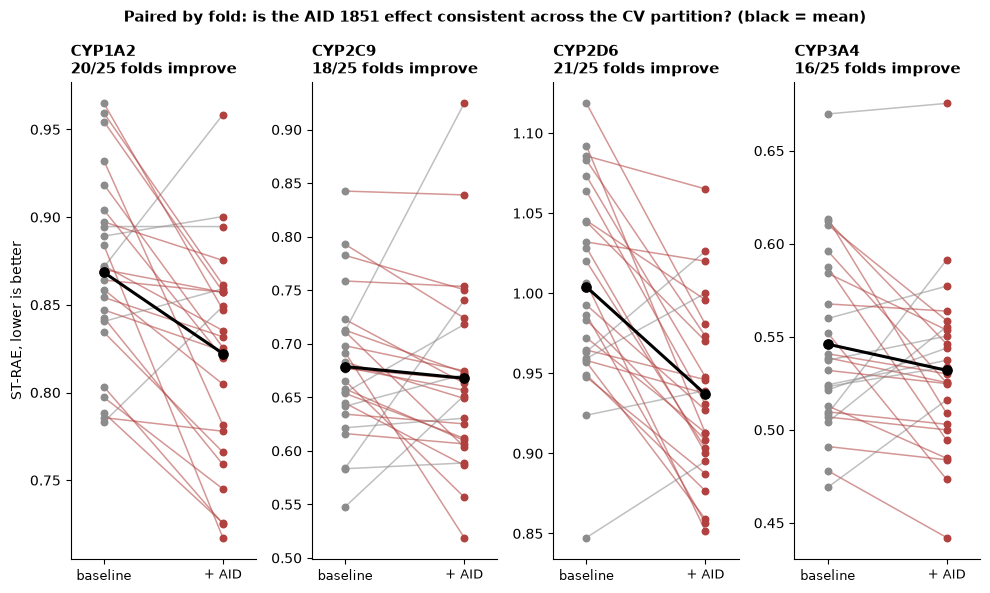

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation/figures/strae_paired_by_fold.png


In [67]:
BASELINE_COLOR = "#8C8C8C"
ACCENT_COLOR = "#B0413E"
plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Figure 1 -- strae_paired_by_fold.png
# Caption: The figure that carries the argument. Each line is one CV fold, joining that
# fold's baseline ST-RAE to its AID ST-RAE. A consistent effect shows as lines sloping the
# same way; an inconsistent one shows as a tangle. Downward (red) = the AID arm is better.
fig, axes = plt.subplots(1, 4, figsize=(10, 6), sharex=True)
for ax, iso in zip(axes, ISOFORMS):
    b, a, keys = fold_matrix("ST-RAE", iso)
    n_down = int((a < b).sum())
    for bi, ai in zip(b, a):
        ax.plot([0, 1], [bi, ai], color=(ACCENT_COLOR if ai < bi else BASELINE_COLOR),
                alpha=0.55, linewidth=1.1, zorder=1)
    ax.scatter([0] * len(b), b, s=22, color=BASELINE_COLOR, zorder=2)
    ax.scatter([1] * len(a), a, s=22, color=ACCENT_COLOR, zorder=2)
    ax.plot([0, 1], [b.mean(), a.mean()], color="black", linewidth=2.2, zorder=3)
    ax.scatter([0, 1], [b.mean(), a.mean()], s=45, color="black", zorder=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["baseline", "+ AID"], fontsize=9)
    ax.set_xlim(-0.28, 1.28)
    ax.set_title(f"{iso}\n{n_down}/{len(b)} folds improve", fontsize=10.5, fontweight="bold", loc="left")
    strip_axes(ax)
axes[0].set_ylabel("ST-RAE, lower is better")
fig.suptitle("Paired by fold: is the AID 1851 effect consistent across the CV partition? "
             "(black = mean)", fontsize=11, fontweight="bold")
plt.tight_layout()
f1 = FIG_OUT / "strae_paired_by_fold.png"
fig.savefig(f1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f1}")

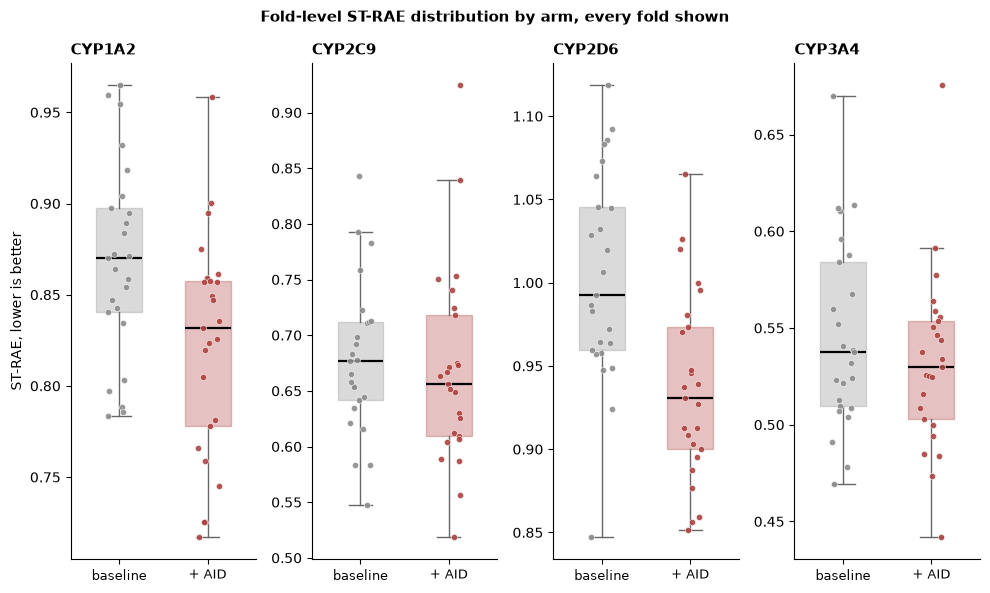

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation/figures/strae_distribution_by_arm.png


In [68]:
# Figure 2 -- strae_distribution_by_arm.png
# Caption: Fold-level ST-RAE distribution per arm, with every fold drawn as a point. Shows
# whether the two arms' distributions separate or merely shift, which is the distinction
# that made notebook 28's CYP2C9 verdict fragile at three seeds.
fig, axes = plt.subplots(1, 4, figsize=(10, 6), sharex=True)
rng = np.random.default_rng(0)
for ax, iso in zip(axes, ISOFORMS):
    b, a, _ = fold_matrix("ST-RAE", iso)
    bp = ax.boxplot([b, a], positions=[0, 1], widths=0.52, showfliers=False,
                    patch_artist=True, medianprops=dict(color="black", linewidth=1.6))
    for patch, col in zip(bp["boxes"], [BASELINE_COLOR, ACCENT_COLOR]):
        patch.set_facecolor(col); patch.set_alpha(0.32); patch.set_edgecolor(col)
    for w in bp["whiskers"] + bp["caps"]:
        w.set_color("#666666")
    for pos, vals, col in [(0, b, BASELINE_COLOR), (1, a, ACCENT_COLOR)]:
        ax.scatter(pos + rng.uniform(-0.13, 0.13, len(vals)), vals, s=20, color=col,
                   alpha=0.9, zorder=3, edgecolors="white", linewidths=0.4)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["baseline", "+ AID"], fontsize=9)
    ax.set_xlim(-0.55, 1.55)
    ax.set_title(iso, fontsize=10.5, fontweight="bold", loc="left")
    strip_axes(ax)
axes[0].set_ylabel("ST-RAE, lower is better")
fig.suptitle("Fold-level ST-RAE distribution by arm, every fold shown",
             fontsize=11, fontweight="bold")
plt.tight_layout()
f2 = FIG_OUT / "strae_distribution_by_arm.png"
fig.savefig(f2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f2}")

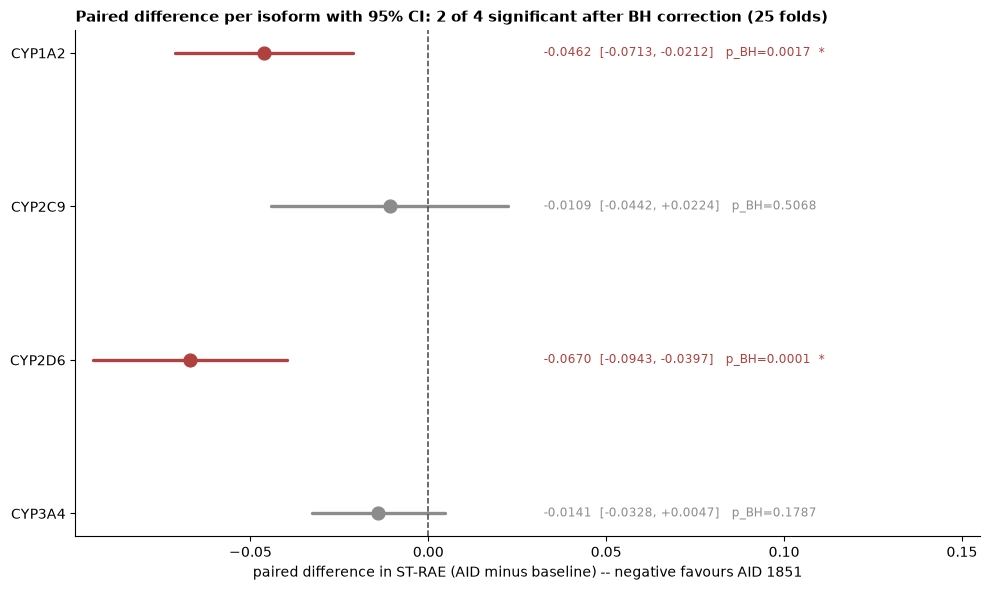

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation/figures/paired_difference_forest.png


In [69]:
# Figure 3 -- paired_difference_forest.png
# Caption: Mean paired difference (AID minus baseline) per isoform with its 95% confidence
# interval. Left of zero favours the AID arm. An interval that crosses zero is an
# unresolved difference regardless of where its point estimate sits.
fig, ax = plt.subplots(figsize=(10, 6))
ys = np.arange(len(ISOFORMS))[::-1]
ann = []
for y, iso in zip(ys, ISOFORMS):
    r = st[st["isoform"] == iso].iloc[0]
    sig = bool(r["significant_bh_0.05"])
    col = ACCENT_COLOR if (sig and r["mean_diff"] < 0) else ("#7A2E2C" if sig else BASELINE_COLOR)
    ax.plot([r["ci_low"], r["ci_high"]], [y, y], color=col, linewidth=2.4, solid_capstyle="round")
    ax.scatter([r["mean_diff"]], [y], s=85, color=col, zorder=3)
    ann.append((y, col, f"{r['mean_diff']:+.4f}  [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]   "
                          f"p_BH={r['p_bh']:.4f}{'  *' if sig else ''}"))
text_x = max(st["ci_high"].max(), 0.0) + 0.010
for y, col, txt in ann:
    ax.text(text_x, y, txt, va="center", ha="left", fontsize=8.5, color=col)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1.1)
ax.set_yticks(ys); ax.set_yticklabels(ISOFORMS)
ax.set_xlabel("paired difference in ST-RAE (AID minus baseline) -- negative favours AID 1851")
xs = np.concatenate([st["ci_low"].values, st["ci_high"].values, [0]])
pad = 0.35 * (xs.max() - xs.min() + 1e-9)
ax.set_xlim(xs.min() - 0.12 * pad, text_x + 3.0 * pad)
strip_axes(ax)
n_sig = int(st["significant_bh_0.05"].sum())
ax.set_title(f"Paired difference per isoform with 95% CI: "
             f"{n_sig} of 4 significant after BH correction "
             f"({len(COMPLETE_FOLDS)} folds)",
             fontsize=11, fontweight="bold", loc="left")
plt.tight_layout()
f3 = FIG_OUT / "paired_difference_forest.png"
fig.savefig(f3, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {f3}")

## Part 6 — Verdict

In [70]:
print("=" * 86)
print(f"VERDICT -- {len(COMPLETE_FOLDS)} complete folds, one seed per fold, "
      f"BH-corrected across four isoforms")
print("=" * 86)
print()
VERDICT_BY_ISO = {}
for iso in ISOFORMS:
    r = st[st["isoform"] == iso].iloc[0]
    if bool(r["significant_bh_0.05"]):
        v = "SIGNIFICANTLY BETTER" if r["mean_diff"] < 0 else "SIGNIFICANTLY WORSE"
    else:
        v = "NOT DIFFERENT"
    VERDICT_BY_ISO[iso] = v
    b, a, _ = fold_matrix("ST-RAE", iso)
    print(f"{iso}: {v}")
    print(f"    baseline {r['mean_baseline']:.4f} -> aid {r['mean_aid']:.4f}   "
          f"diff {r['mean_diff']:+.4f}  95% CI [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]")
    print(f"    {r['test']}: stat={r['stat']:.4f}  p={r['p']:.5f}  p_BH={r['p_bh']:.5f}  "
          f"{r['effect_name']}={r['effect']:+.3f}")
    print(f"    folds improving: {int((a < b).sum())}/{len(b)}")
    print()

print("-" * 86)
print("DID NOTEBOOK 28's SINGLE-FOLD VERDICTS REPRODUCE?")
print("-" * 86)
REPRO = {}
for iso in ISOFORMS:
    nb28v = NB28_SINGLE_FOLD_VERDICT[iso]
    now = VERDICT_BY_ISO[iso]
    if nb28v == "IMPROVES":
        held = (now == "SIGNIFICANTLY BETTER")
    else:
        held = (now == "NOT DIFFERENT")
    REPRO[iso] = held
    print(f"  {iso:8s} nb28={nb28v:11s} -> nb29={now:22s}  {'REPRODUCED' if held else 'DID NOT REPRODUCE'}")
print()
print("A screen result failing to reproduce at full CV is a real and useful finding, not a")
print("failure of execution -- it is the reason this confirmation run exists.")

VERDICT -- 25 complete folds, one seed per fold, BH-corrected across four isoforms

CYP1A2: SIGNIFICANTLY BETTER
    baseline 0.8685 -> aid 0.8222   diff -0.0462  95% CI [-0.0713, -0.0212]
    paired t-test: stat=-3.8062  p=0.00086  p_BH=0.00172  Cohen's dz=-0.761
    folds improving: 20/25

CYP2C9: NOT DIFFERENT
    baseline 0.6787 -> aid 0.6678   diff -0.0109  95% CI [-0.0442, +0.0224]
    paired t-test: stat=-0.6740  p=0.50678  p_BH=0.50678  Cohen's dz=-0.135
    folds improving: 18/25

CYP2D6: SIGNIFICANTLY BETTER
    baseline 1.0039 -> aid 0.9369   diff -0.0670  95% CI [-0.0943, -0.0397]
    paired t-test: stat=-5.0711  p=0.00003  p_BH=0.00014  Cohen's dz=-1.014
    folds improving: 21/25

CYP3A4: NOT DIFFERENT
    baseline 0.5461 -> aid 0.5320   diff -0.0141  95% CI [-0.0328, +0.0047]
    paired t-test: stat=-1.5509  p=0.13400  p_BH=0.17867  Cohen's dz=-0.310
    folds improving: 16/25

--------------------------------------------------------------------------------------
DID NOT

In [71]:
print("-" * 86)
print("ERROR-CORRELATION VERDICT (separate from solo performance)")
print("-" * 86)
changed = []
for _, r in corr_df.iterrows():
    inband = NB24_BAND[0] <= r["aid_vs_baseline_mean"] <= NB24_BAND[1]
    below = r["aid_vs_baseline_mean"] < NB24_BAND[0]
    print(f"  {r['isoform']:8s} {r['aid_vs_baseline_mean']:.4f}  "
          f"(nb28 single-fold range {NB28_RANGE[0]}-{NB28_RANGE[1]}; "
          f"nb24 pool band {NB24_BAND[0]}-{NB24_BAND[1]})  "
          f"{'BELOW band -- ensemble candidate' if below else ('in band' if inband else 'above band')}")
    if below:
        changed.append(r["isoform"])
print()
if changed:
    print(f"CHANGED: {changed} now sit below notebook 24's band -- a genuine ensemble case for those.")
else:
    print("UNCHANGED from notebook 28: the AID arm is NOT decorrelated from the baseline.")
    print("Its value is as a better single model, not as a diverse ensemble member. This is")
    print("reported as a separate verdict from the solo ST-RAE result above.")

print()
print("-" * 86)
print("CYP2D6 CAVEAT, REPEATED IN THE VERDICT AS REQUIRED")
print("-" * 86)
print("Notebook 21 established OOF ST-RAE is not a valid selection metric for CYP2D6, and the")
print("real board has contradicted OOF evidence for that isoform twice (the deployed")
print(f"recentring, and the spread widening). CYP2D6's result here ({VERDICT_BY_ISO['CYP2D6']})")
print("is measured against a population that is not the one being scored, and must not on its")
print("own justify a CYP2D6 modelling decision.")

n_better = sum(1 for v in VERDICT_BY_ISO.values() if v == "SIGNIFICANTLY BETTER")
n_worse = sum(1 for v in VERDICT_BY_ISO.values() if v == "SIGNIFICANTLY WORSE")
VERDICT = {
    "notebook": "29_cv_confirmation",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "design": DESIGN, "n_complete_folds": len(COMPLETE_FOLDS),
    "folds": [list(x) for x in COMPLETE_FOLDS],
    "per_isoform_verdict": VERDICT_BY_ISO,
    "nb28_verdict": NB28_SINGLE_FOLD_VERDICT,
    "nb28_reproduced": REPRO,
    "strae_table": st.to_dict(orient="records"),
    "macro": resM,
    "error_correlation": corr_df.to_dict(orient="records"),
    "ensemble_candidate_isoforms": changed,
    "n_significantly_better": n_better, "n_significantly_worse": n_worse,
    "submission_recommendation": "none -- report-only confirmation run; no submission built",
    "aborted": ABORT,
}
with open(OUT / "verdict.json", "w") as fh:
    json.dump(VERDICT, fh, indent=2, default=float)
print(f"\nwrote {OUT / 'verdict.json'}")

--------------------------------------------------------------------------------------
ERROR-CORRELATION VERDICT (separate from solo performance)
--------------------------------------------------------------------------------------
  CYP1A2   0.9022  (nb28 single-fold range 0.844-0.927; nb24 pool band 0.79-0.91)  in band
  CYP2C9   0.8806  (nb28 single-fold range 0.844-0.927; nb24 pool band 0.79-0.91)  in band
  CYP2D6   0.9334  (nb28 single-fold range 0.844-0.927; nb24 pool band 0.79-0.91)  above band
  CYP3A4   0.8498  (nb28 single-fold range 0.844-0.927; nb24 pool band 0.79-0.91)  in band

UNCHANGED from notebook 28: the AID arm is NOT decorrelated from the baseline.
Its value is as a better single model, not as a diverse ensemble member. This is
reported as a separate verdict from the solo ST-RAE result above.

--------------------------------------------------------------------------------------
CYP2D6 CAVEAT, REPEATED IN THE VERDICT AS REQUIRED
----------------------------------

### Does this warrant a full-data retrain and submission?

**Qualified yes for CYP1A2, and nothing is built here.** Stated per isoform, because the
four do not point the same way:

- **CYP1A2 — the defensible case.** Significantly better (−0.0462, 95% CI [−0.0713,
  −0.0212], p_BH=0.0017, Cohen's dz=−0.76, 20/25 folds improving), and it is the **one
  isoform whose screen verdict reproduced**. A properly-powered repeated-measures result on
  the project's own frozen partition is the strongest modelling evidence this project has
  produced. It is also, after CYP2D6, this project's weakest isoform on the real board, so
  the headroom is real.
- **CYP2D6 — statistically the strongest, and the least actionable.** Largest effect
  (−0.0670, dz=−1.01, p_BH=0.00014, 21/25 folds). But notebook 21 established OOF ST-RAE is
  not a valid selection metric for this isoform, and the board has contradicted OOF evidence
  for it **twice**. This number is measured against a population that is not the one being
  scored. It should **not** on its own justify a CYP2D6 decision, and the temptation to bank
  it because it is the biggest number is exactly what this caveat exists to resist.
- **CYP2C9 and CYP3A4 — no case.** Not different (p_BH=0.507 and 0.179), CIs spanning zero.

**Three reasons for caution even on CYP1A2.** This project has been here before: notebook
08's ensembles showed CV margins that were *fully erased* on blind data, and notebooks 10
and 12 both regressed on the board after CV said they would not. Second, `CLAUDE.md`'s own
rule requires an adoption decision to rest on an effect-size threshold frozen *before*
results — the threshold frozen for this run was a confirmation threshold, not an adoption
one, so adoption remains a separate, later decision. Third, a submission would deploy the
whole 8-head model, including the two isoforms where it demonstrably does nothing; whether
to accept a no-op on CYP2C9/CYP3A4 in exchange for CYP1A2 is a judgement about submission
strategy, not a statistical question this notebook can settle.

**What is genuinely new here:** this is the first lever tested on this project that **adds
information** rather than rearranging what was already present, and the first to survive a
properly-powered test. Notebook 28's headline — "all four isoforms improve" — did **not**
survive: two of four are indistinguishable from zero at 25 folds.

**No submission was built, validated or sent. No full-data retrain. No ensemble. No third
arm.** Per the scope boundaries.

## Decisions taken without approval

This section is required by the task's autonomy rules and is present even when empty. It
records every choice made where the specification was genuinely underdetermined, together
with the alternatives considered and the reasoning. The governing rule was to take the
option that changes least from notebook 28's already-executed configuration.

In [72]:
print("DECISIONS TAKEN WITHOUT APPROVAL")
print("=" * 86)
if not AUTONOMOUS_DECISIONS:
    print("None. Every choice in this run was pre-specified by the task brief or inherited")
    print("unchanged from notebook 28's executed configuration.")
else:
    for i, d in enumerate(AUTONOMOUS_DECISIONS, 1):
        print(f"\n{i}. {d['decision']}")
        print(f"   Reason:       {d['reason']}")
        print(f"   Alternatives: {d['alternatives']}")
        print(f"   Authority:    {d['authority']}")
with open(OUT / "autonomous_decisions.json", "w") as fh:
    json.dump(AUTONOMOUS_DECISIONS, fh, indent=2, default=str)
print(f"\n\nwrote {OUT / 'autonomous_decisions.json'}")

print()
print("RUN ABORTED?")
print("=" * 86)
if ABORT["aborted"]:
    print(f"YES -- {ABORT['reason']}")
    print(f"       at {ABORT['where']}")
    print("       Partial results are on disk in run_scores.csv and predictions/.")
    print("       Re-executing this notebook resumes from the cache; no completed fold is lost.")
else:
    print("No. The run completed without a hard failure.")

DECISIONS TAKEN WITHOUT APPROVAL
None. Every choice in this run was pre-specified by the task brief or inherited
unchanged from notebook 28's executed configuration.


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/29_cv_confirmation/autonomous_decisions.json

RUN ABORTED?
No. The run completed without a hard failure.


In [73]:
# Scope check. Two independent tests, because the first version of this check was WRONG and
# raised a false positive on its own first run: it substring-matched protected paths against
# git status lines without reading the status CODE, so `?? outputs/28_external_data/` -- an
# UNTRACKED directory, untracked because notebook 28's outputs were never committed, which
# is its pre-existing state and not something this notebook did -- was reported as a
# modification. Recorded here rather than quietly corrected.
st_out = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True,
                        cwd=REPO_ROOT).stdout
print("git status --porcelain:")
print(st_out if st_out.strip() else "(clean)")

PROTECTED = ["data/folds/cv_folds.csv", "data/processed/", "data/raw/",
             "outputs/05_cv_comparison/", "outputs/11_caruana_prep/", "outputs/27_calibration/",
             "outputs/28_external_data/", "outputs/board_solved_calibration/",
             "outputs/19_cyp2c9_revert/", "src/"]

# TEST 1 -- a CHANGE to tracked content under a protected path. `??` (untracked) is skipped
# here and covered by TEST 2 instead.
tracked_violations = []
for line in st_out.splitlines():
    code, path = line[:2], line[3:].strip()
    if not any(x in path for x in PROTECTED):
        continue
    if code.strip() == "??":
        continue
    tracked_violations.append(line)

# TEST 2 -- nothing inside a protected tree may have been WRITTEN during this run. This is
# what actually protects the untracked trees, and it is strictly stronger than the git check
# for them.
written_during_run = []
for prot in PROTECTED:
    q = REPO_ROOT / prot
    if not q.exists():
        continue
    candidates = [q] if q.is_file() else [x for x in q.rglob("*") if x.is_file()]
    for fp in candidates:
        try:
            if fp.stat().st_mtime > RUN_STARTED_AT:
                written_during_run.append(str(fp.relative_to(REPO_ROOT)))
        except OSError:
            pass

print()
print(f"TEST 1 -- tracked modifications under a protected path: {len(tracked_violations)}")
for t in tracked_violations:
    print(f"    VIOLATION: {t}")
print(f"TEST 2 -- files written inside a protected tree during this run: {len(written_during_run)}")
for t in written_during_run[:20]:
    print(f"    VIOLATION: {t}")

if tracked_violations or written_during_run:
    raise ValueError("a protected path was modified -- investigate")
print()
print("confirmed: no protected path modified, by either test.")
print(f"outputs written by this notebook: {sorted(q.name for q in OUT.iterdir())}")

git status --porcelain:
 M CLAUDE.md
?? notebooks/28_external_data.ipynb
?? notebooks/29_cv_confirmation.ipynb
?? outputs/28_external_data/
?? outputs/29_cv_confirmation/


TEST 1 -- tracked modifications under a protected path: 0
TEST 2 -- files written inside a protected tree during this run: 0

confirmed: no protected path modified, by either test.
outputs written by this notebook: ['autonomous_decisions.json', 'chemprop_runs', 'design.json', 'error_correlation.csv', 'figures', 'macro_result.json', 'paired_tests_mae.csv', 'paired_tests_strae.csv', 'predictions', 'run_scores.csv', 'run_timings.csv', 'scores', 'verdict.json', 'winsor_bounds_by_fold.csv']
